# Projeto Churn - Redes Neurais 2025.2

Aplicação das seguintes redes neurais e classificadores

- Multilayer Perceptron (MLP)
- STab
- TabPFN v2 Transformer
- KAN
- TabKAN
- Mitra
- Gradient Boosting

na base de dados ```customer_churn_telecom_services.csv``` para prever se um cliente vai abandonar ou não a empresa de telecom.

* Isaac Manoel Teixeira da Silva
(imts2@cin.ufpe.br)
* Lucas Emmanuel Soares de Araujo Francisco
(lesaf@cin.ufpe.br)
* Marcelo Henrique Alexandre Barreiros
(mhab@cin.ufpe.br)
* Rodrigo Rocha Moura (rrm2@cin.ufpe.br)

# **Import de bibliotecas**

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler

# **Import e Particionamento do Dataset**

## Import do Dataset

In [ ]:
# Upload
uploaded = files.upload()

# Pega o nome do arquivo (primeira chave do dict)
filename = next(iter(uploaded))
df = pd.read_csv(filename)

print("Dataset carregado com sucesso!")
df.head()

Saving customer_churn_telecom_services.csv to customer_churn_telecom_services.csv
Dataset carregado com sucesso!


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Convertendo o Dataset para valores numéricos

In [ ]:
# 1) Converter coluna Churn para binário
df['Churn'] = df['Churn'].map({"No": 0, "Yes": 1})

# Tratar 'TotalCharges': converter para numérico e preencher NaN's com 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# 2) Identificar colunas numéricas e categóricas
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns

print("Colunas categóricas:", list(categorical_cols))
print("Colunas numéricas:", list(numeric_cols))

# 3) Converter booleanas para 0/1
for col in categorical_cols:
    if df[col].dtype == bool:
        df[col] = df[col].astype(int)

# 4) Aplicar One-Hot Encoding nas categóricas
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nConversão concluída!")
print("Shape original:", df.shape)
print("Shape convertido:", df_encoded.shape)

df_encoded.head()

Colunas categóricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Colunas numéricas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']

Conversão concluída!
Shape original: (7043, 20)
Shape convertido: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


## Separando Dataset em 2 Classes

In [ ]:
# Verifique os valores de classe
print(df_encoded['Churn'].value_counts())

# Separação das classes
classe_0 = df_encoded[df_encoded['Churn'] == 0]
classe_1 = df_encoded[df_encoded['Churn'] == 1]

Churn
0    5174
1    1869
Name: count, dtype: int64


## Separação de classes em 50% Treino, 25% Validação e 25% Teste

In [ ]:
def split_50_25_25(data):
    # 50% treino e 50% restante
    train, temp = train_test_split(data, test_size=0.5, shuffle=True, random_state=42)

    # Dos 50% restantes → metade vira validação, metade vira teste
    val, test = train_test_split(temp, test_size=0.5, shuffle=True, random_state=42)

    return train, val, test

In [ ]:
train_0, val_0, test_0 = split_50_25_25(classe_0)
train_1, val_1, test_1 = split_50_25_25(classe_1)

## Reunindo as Classes mantendo o balanceamento (Oversampling)

In [ ]:
from imblearn.over_sampling import RandomOverSampler

# -- 1) Reunir classes em suas divisões (treino, validação e teste)
train = pd.concat([train_0, train_1]).sample(frac=1, random_state=42)
val = pd.concat([val_0, val_1]).sample(frac=1, random_state=42)
test = pd.concat([test_0, test_1]).sample(frac=1, random_state=42)

X_train = train.drop("Churn", axis=1)
y_train = train["Churn"]

# -- 2) Balanceamento
oversample = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = oversample.fit_resample(X_train, y_train)

# -- 3) Recriar dataframe balanceado
train_bal = pd.concat([X_train_bal, y_train_bal], axis=1)
train_bal = train_bal.sample(frac=1, random_state=42).reset_index(drop=True)

### Normalização dos dados balanceados

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# 1) Separar features e target
X_train_bal = train_bal.drop("Churn", axis=1)
y_train_bal = train_bal["Churn"]

X_val = val.drop("Churn", axis=1)
y_val = val["Churn"]

X_test = test.drop("Churn", axis=1)
y_test = test["Churn"]

# 2) Ajustar o scaler SOMENTE no treino balanceado
scaler.fit(X_train_bal)

# 3) Transformar treino/validação/teste
X_train_scaled = scaler.transform(X_train_bal)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print("Tamanhos finais:")
print("Treino:", X_train_scaled.shape)
print("Validação:", X_val_scaled.shape)
print("Teste:", X_test_scaled.shape)

print("\nDistribuição de classes:")
print("Treino:\n", y_train_bal.value_counts())
print("Validação:\n", y_val.value_counts())
print("Teste:\n", y_test.value_counts())

Tamanhos finais:
Treino: (5174, 30)
Validação: (1760, 30)
Teste: (1762, 30)

Distribuição de classes:
Treino:
 Churn
1    2587
0    2587
Name: count, dtype: int64
Validação:
 Churn
0    1293
1     467
Name: count, dtype: int64
Teste:
 Churn
0    1294
1     468
Name: count, dtype: int64


# **Experimentos**

## Experimento com MLP

In [ ]:
!pip install -q optuna torch scikit-learn numpy pandas

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
import pandas as pd
import numpy as np
import optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 26.8 MB/s eta 0:00:00


### Função KS

In [ ]:
# -----------------------------------------------------
# Função KS
# -----------------------------------------------------
def ks_statistic(y_true, y_prob):
    df = pd.DataFrame({"y": y_true, "p": y_prob})
    df = df.sort_values("p", ascending=False)

    cum_event = np.cumsum(df["y"]) / df["y"].sum()
    cum_non_event = np.cumsum(1 - df["y"]) / (1 - df["y"]).sum()

    ks = np.max(np.abs(cum_event - cum_non_event))
    return ks


# -----------------------------------------------------
# Converte dataframe em tensores PyTorch
# -----------------------------------------------------
def to_tensor(X, y):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y.values, dtype=torch.float32)
    return X_tensor, y_tensor


### Modelo MLP

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, dropout):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).squeeze()

### Função de Treino e Avaliação

In [ ]:
def train_model(model, X_train, y_train, X_val, y_val, lr, epochs=20, patience=5):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    best_val_score = -float('inf')
    best_ks = 0
    best_acc = 0
    patience_counter = 0

    # ==========================
    #     HISTÓRICO P/ GRÁFICOS
    # ==========================
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "val_ks": [],
    }

    for epoch in range(epochs):

        # ---------- TREINO ----------
        model.train()
        optimizer.zero_grad()
        y_pred_train = model(X_train)
        loss = criterion(y_pred_train, y_train)
        loss.backward()
        optimizer.step()

        # ---------- VALIDAÇÃO ----------
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val).numpy()

        current_ks = ks_statistic(y_val.numpy(), val_pred)
        current_acc = accuracy_score(y_val.numpy(), (val_pred > 0.5).astype(int))

        # loss de validação
        val_loss = nn.BCELoss()(torch.tensor(val_pred, dtype=torch.float32), y_val).item()

        # ------ salvar histórico ------
        history["train_loss"].append(loss.item())
        history["val_loss"].append(val_loss)
        history["val_acc"].append(current_acc)
        history["val_ks"].append(current_ks)

        # ------ Early Stopping ------
        current_combined_score = current_ks + current_acc * 0.01

        if current_combined_score > best_val_score:
            best_val_score = current_combined_score
            best_ks = current_ks
            best_acc = current_acc
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Loss: {loss.item():.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val KS: {current_ks:.4f} | "
              f"Val Acc: {current_acc:.4f}")

    return history, best_ks, best_acc

### Função Objetivo para Optuna (Maximiza KS e Acurácia) e Procura de melhores Hiperparâmetros

In [ ]:
def objective(trial):
    # Hiperparâmetros
    hidden1 = trial.suggest_int("hidden1", 16, 128)
    hidden2 = trial.suggest_int("hidden2", 8, 64)
    dropout = trial.suggest_float("dropout", 0.0, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    patience = trial.suggest_int("patience", 5, 20)

    # Modelo
    input_dim = X_train_scaled.shape[1]
    model = MLP(input_dim, hidden1, hidden2, dropout)

    # Tensores
    X_train_tensor, y_train_tensor = to_tensor(X_train_scaled, y_train_bal)
    X_val_tensor, y_val_tensor = to_tensor(X_val_scaled, y_val)

    # Treinar
    history, ks, acc = train_model(
        model,
        X_train_tensor, y_train_tensor,
        X_val_tensor, y_val_tensor,
        lr,
        epochs=50,
        patience=patience
    )

    # Otimização: KS como métrica principal
    return ks + acc * 0.01

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100) # Mantive 100 trials, você pode aumentar se quiser explorar mais o novo hiperparâmetro

print("Melhores parâmetros:")
print(study.best_params)

[I 2025-12-13 19:11:42,272] A new study created in memory with name: no-name-941ba170-4e90-437d-839e-a02e2e182875


Epoch 1/50 | Loss: 0.7047 | Val Loss: 0.7096 | Val KS: 0.2991 | Val Acc: 0.3261
Epoch 2/50 | Loss: 0.7023 | Val Loss: 0.7064 | Val KS: 0.2527 | Val Acc: 0.3432
Epoch 3/50 | Loss: 0.7000 | Val Loss: 0.7033 | Val KS: 0.1724 | Val Acc: 0.3608
Epoch 4/50 | Loss: 0.6982 | Val Loss: 0.7002 | Val KS: 0.1137 | Val Acc: 0.3915
Epoch 5/50 | Loss: 0.6963 | Val Loss: 0.6972 | Val KS: 0.0662 | Val Acc: 0.4364
Epoch 6/50 | Loss: 0.6941 | Val Loss: 0.6942 | Val KS: 0.0652 | Val Acc: 0.4824
Epoch 7/50 | Loss: 0.6931 | Val Loss: 0.6913 | Val KS: 0.1183 | Val Acc: 0.5398
Epoch 8/50 | Loss: 0.6907 | Val Loss: 0.6884 | Val KS: 0.1866 | Val Acc: 0.6000
Epoch 9/50 | Loss: 0.6886 | Val Loss: 0.6855 | Val KS: 0.2506 | Val Acc: 0.6392
Epoch 10/50 | Loss: 0.6869 | Val Loss: 0.6827 | Val KS: 0.3018 | Val Acc: 0.6665
Epoch 11/50 | Loss: 0.6861 | Val Loss: 0.6799 | Val KS: 0.3403 | Val Acc: 0.6994
Epoch 12/50 | Loss: 0.6838 | Val Loss: 0.6772 | Val KS: 0.3643 | Val Acc: 0.7148
Epoch 13/50 | Loss: 0.6818 | Val Loss

[I 2025-12-13 19:12:07,551] Trial 0 finished with value: 0.5361122815392234 and parameters: {'hidden1': 58, 'hidden2': 60, 'dropout': 0.1073573509239455, 'lr': 0.00034601989584192173, 'patience': 18}. Best is trial 0 with value: 0.5361122815392234.


Epoch 49/50 | Loss: 0.6077 | Val Loss: 0.5707 | Val KS: 0.5284 | Val Acc: 0.7665
Epoch 50/50 | Loss: 0.6065 | Val Loss: 0.5676 | Val KS: 0.5283 | Val Acc: 0.7648
Epoch 1/50 | Loss: 0.6989 | Val Loss: 0.6998 | Val KS: 0.4569 | Val Acc: 0.4119
Epoch 2/50 | Loss: 0.6758 | Val Loss: 0.6641 | Val KS: 0.5265 | Val Acc: 0.6733
Epoch 3/50 | Loss: 0.6529 | Val Loss: 0.6302 | Val KS: 0.5320 | Val Acc: 0.7341
Epoch 4/50 | Loss: 0.6337 | Val Loss: 0.5978 | Val KS: 0.5417 | Val Acc: 0.7580
Epoch 5/50 | Loss: 0.6146 | Val Loss: 0.5673 | Val KS: 0.5457 | Val Acc: 0.7648
Epoch 6/50 | Loss: 0.5972 | Val Loss: 0.5396 | Val KS: 0.5448 | Val Acc: 0.7699
Epoch 7/50 | Loss: 0.5804 | Val Loss: 0.5159 | Val KS: 0.5469 | Val Acc: 0.7688
Epoch 8/50 | Loss: 0.5671 | Val Loss: 0.4977 | Val KS: 0.5441 | Val Acc: 0.7653
Epoch 9/50 | Loss: 0.5535 | Val Loss: 0.4851 | Val KS: 0.5441 | Val Acc: 0.7619
Epoch 10/50 | Loss: 0.5461 | Val Loss: 0.4783 | Val KS: 0.5448 | Val Acc: 0.7631
Epoch 11/50 | Loss: 0.5393 | Val Loss

[I 2025-12-13 19:12:11,183] Trial 1 finished with value: 0.5603998271768743 and parameters: {'hidden1': 115, 'hidden2': 31, 'dropout': 0.2332980541157092, 'lr': 0.003127061601154982, 'patience': 18}. Best is trial 1 with value: 0.5603998271768743.


...

Epoch 21/50 | Loss: 0.4964 | Val Loss: 0.4800 | Val KS: 0.5523 | Val Acc: 0.7619
Epoch 22/50 | Loss: 0.4939 | Val Loss: 0.4774 | Val KS: 0.5566 | Val Acc: 0.7636
Epoch 23/50 | Loss: 0.4906 | Val Loss: 0.4771 | Val KS: 0.5587 | Val Acc: 0.7659
Epoch 24/50 | Loss: 0.4898 | Val Loss: 0.4785 | Val KS: 0.5513 | Val Acc: 0.7614
Epoch 1/50 | Loss: 0.6959 | Val Loss: 0.6414 | Val KS: 0.4710 | Val Acc: 0.7773
Epoch 2/50 | Loss: 0.6703 | Val Loss: 0.6115 | Val KS: 0.5198 | Val Acc: 0.7972
Epoch 3/50 | Loss: 0.6481 | Val Loss: 0.5841 | Val KS: 0.5356 | Val Acc: 0.7920
Epoch 4/50 | Loss: 0.6267 | Val Loss: 0.5577 | Val KS: 0.5402 | Val Acc: 0.7830
Epoch 5/50 | Loss: 0.6050 | Val Loss: 0.5327 | Val KS: 0.5396 | Val Acc: 0.7739
Epoch 6/50 | Loss: 0.5844 | Val Loss: 0.5107 | Val KS: 0.5401 | Val Acc: 0.7716
Epoch 7/50 | Loss: 0.5652 | Val Loss: 0.4937 | Val KS: 0.5416 | Val Acc: 0.7665
Epoch 8/50 | Loss: 0.5490 | Val Loss: 0.4834 | Val KS: 0.5449 | Val Acc: 0.7608
Epoch 9/50 | Loss: 0.5375 | Val Loss

[I 2025-12-13 19:13:52,199] Trial 98 finished with value: 0.5740423246730457 and parameters: {'hidden1': 82, 'hidden2': 60, 'dropout': 0.027185510193302773, 'lr': 0.003513963141245186, 'patience': 13}. Best is trial 39 with value: 0.5767232118519869.


Epoch 33/50 | Loss: 0.4804 | Val Loss: 0.4708 | Val KS: 0.5502 | Val Acc: 0.7670
Epoch 34/50 | Loss: 0.4799 | Val Loss: 0.4736 | Val KS: 0.5494 | Val Acc: 0.7653
Epoch 35/50 | Loss: 0.4776 | Val Loss: 0.4772 | Val KS: 0.5462 | Val Acc: 0.7642
Epoch 36/50 | Loss: 0.4765 | Val Loss: 0.4804 | Val KS: 0.5468 | Val Acc: 0.7608
Epoch 1/50 | Loss: 0.6933 | Val Loss: 0.6804 | Val KS: 0.4833 | Val Acc: 0.5835
Epoch 2/50 | Loss: 0.6632 | Val Loss: 0.6374 | Val KS: 0.5162 | Val Acc: 0.7250
Epoch 3/50 | Loss: 0.6366 | Val Loss: 0.5975 | Val KS: 0.5300 | Val Acc: 0.7608
Epoch 4/50 | Loss: 0.6116 | Val Loss: 0.5600 | Val KS: 0.5327 | Val Acc: 0.7676
Epoch 5/50 | Loss: 0.5859 | Val Loss: 0.5269 | Val KS: 0.5365 | Val Acc: 0.7682
Epoch 6/50 | Loss: 0.5633 | Val Loss: 0.5013 | Val KS: 0.5431 | Val Acc: 0.7648
Epoch 7/50 | Loss: 0.5449 | Val Loss: 0.4855 | Val KS: 0.5468 | Val Acc: 0.7597
Epoch 8/50 | Loss: 0.5321 | Val Loss: 0.4796 | Val KS: 0.5464 | Val Acc: 0.7545
Epoch 9/50 | Loss: 0.5249 | Val Loss

[I 2025-12-13 19:13:53,671] Trial 99 finished with value: 0.5611841185743158 and parameters: {'hidden1': 83, 'hidden2': 31, 'dropout': 0.030031266905173798, 'lr': 0.004369143176014414, 'patience': 11}. Best is trial 39 with value: 0.5767232118519869.


Epoch 29/50 | Loss: 0.4819 | Val Loss: 0.4672 | Val KS: 0.5444 | Val Acc: 0.7614
Epoch 30/50 | Loss: 0.4805 | Val Loss: 0.4675 | Val KS: 0.5459 | Val Acc: 0.7636
Melhores parâmetros:
{'hidden1': 88, 'hidden2': 25, 'dropout': 0.23751901343863369, 'lr': 0.005139576335012704, 'patience': 17}


### Treino com os melhores Hiperparâmetros e Gráficos

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score
import matplotlib.pyplot as plt

best = study.best_params
input_dim = train.shape[1] - 1

final_model = MLP(
    input_dim=input_dim,
    hidden1=best["hidden1"],
    hidden2=best["hidden2"],
    dropout=best["dropout"],
)

# Tensores
X_train_tensor, y_train_tensor = to_tensor(X_train_scaled, y_train_bal)
X_val_tensor, y_val_tensor = to_tensor(X_val_scaled, y_val)

# Usando a paciência encontrada pelo Optuna, e um número máximo de épocas razoavelmente alto
history, ks, acc = train_model(final_model, X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, best["lr"], epochs=100, patience=best["patience"])

final_model.eval()
X_test_tensor, y_test_tensor = to_tensor(X_test_scaled, y_test)

with torch.no_grad():
    y_prob = final_model(X_test_tensor).numpy()

y_pred = (y_prob > 0.5).astype(int)

print("Acurácia:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("KS:", ks_statistic(y_test.values, y_prob))


Epoch 1/100 | Loss: 0.7101 | Val Loss: 0.6583 | Val KS: 0.3293 | Val Acc: 0.7307
Epoch 2/100 | Loss: 0.6836 | Val Loss: 0.6260 | Val KS: 0.4913 | Val Acc: 0.7807
Epoch 3/100 | Loss: 0.6611 | Val Loss: 0.5931 | Val KS: 0.5183 | Val Acc: 0.7892
Epoch 4/100 | Loss: 0.6415 | Val Loss: 0.5609 | Val KS: 0.5287 | Val Acc: 0.7824
Epoch 5/100 | Loss: 0.6234 | Val Loss: 0.5330 | Val KS: 0.5317 | Val Acc: 0.7778
Epoch 6/100 | Loss: 0.6078 | Val Loss: 0.5110 | Val KS: 0.5358 | Val Acc: 0.7744
Epoch 7/100 | Loss: 0.5888 | Val Loss: 0.4944 | Val KS: 0.5350 | Val Acc: 0.7705
Epoch 8/100 | Loss: 0.5750 | Val Loss: 0.4841 | Val KS: 0.5401 | Val Acc: 0.7597
Epoch 9/100 | Loss: 0.5593 | Val Loss: 0.4814 | Val KS: 0.5440 | Val Acc: 0.7545
Epoch 10/100 | Loss: 0.5448 | Val Loss: 0.4875 | Val KS: 0.5397 | Val Acc: 0.7477
Epoch 11/100 | Loss: 0.5344 | Val Loss: 0.5019 | Val KS: 0.5402 | Val Acc: 0.7398
Epoch 12/100 | Loss: 0.5287 | Val Loss: 0.5189 | Val KS: 0.5432 | Val Acc: 0.7352
Epoch 13/100 | Loss: 0.53

Acurácia: 0.7451759364358683
F1: 0.6261448792672772
AUC: 0.8377529756007345
KS: 0.5300763550377152


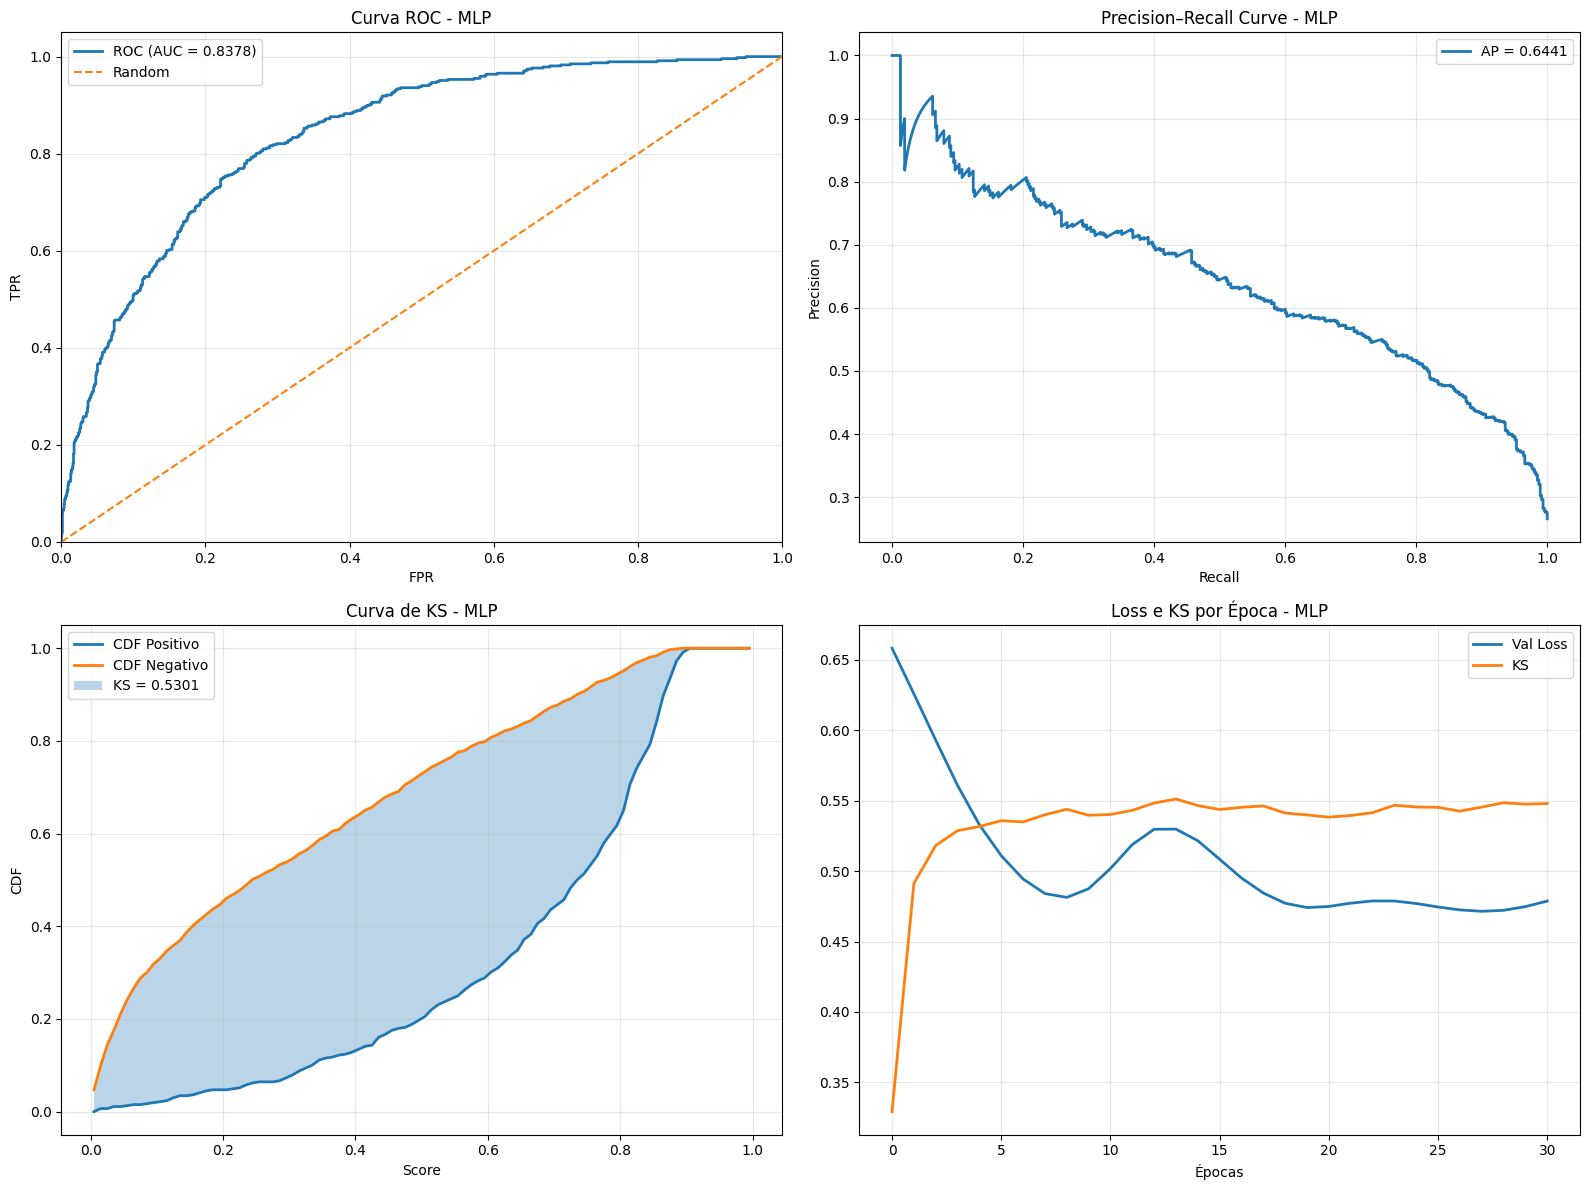

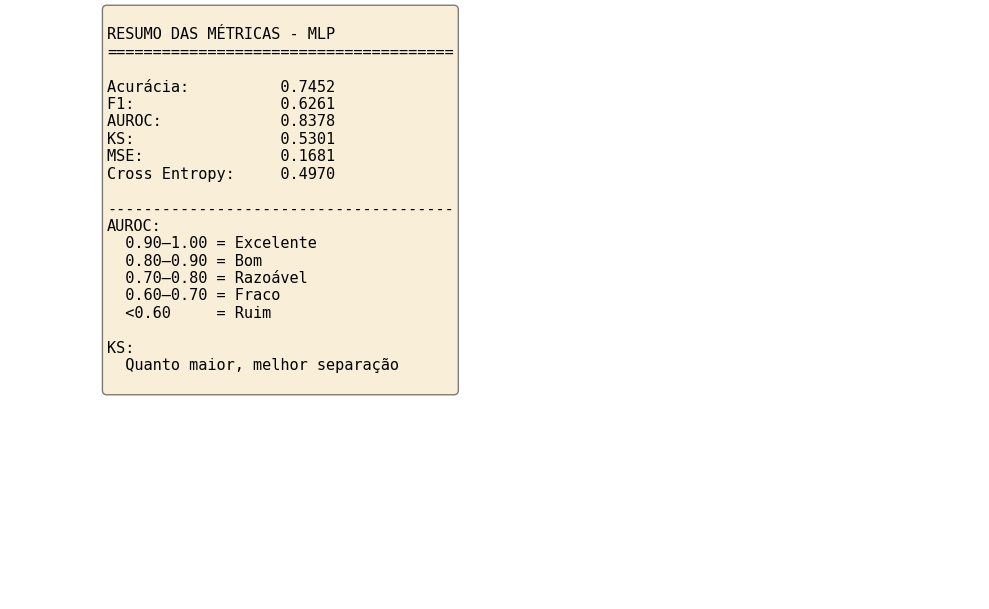

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, mean_squared_error, log_loss
import matplotlib.pyplot as plt

# ================================
#  MÉTRICAS BÁSICAS
# ================================
print("Acurácia:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("KS:", ks_statistic(y_test, y_prob))

# ================================
#  GRÁFICOS PRINCIPAIS
# ================================

plt.figure(figsize=(16,12))

# ---------------- ROC ----------------
ax_roc = plt.subplot(2,2,1)
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

ax_roc.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {auc:.4f})')
ax_roc.plot([0,1], [0,1], linestyle='--', label='Random')

ax_roc.set_xlim([0,1])
ax_roc.set_ylim([0,1.05])
ax_roc.set_xlabel("FPR")
ax_roc.set_ylabel("TPR")
ax_roc.set_title("Curva ROC - MLP")
ax_roc.legend()
ax_roc.grid(True, alpha=0.3)

# ------------- Precision–Recall -------------
ax_pr = plt.subplot(2,2,2)

prec, rec, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

ax_pr.plot(rec, prec, lw=2, label=f"AP = {ap:.4f}")
ax_pr.set_title("Precision–Recall Curve - MLP")
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.legend()
ax_pr.grid(True, alpha=0.3)

# ---------------- KS Curve ----------------
ax_ks = plt.subplot(2,2,3)

y_prob_pos = y_prob[y_test == 1]
y_prob_neg = y_prob[y_test == 0]

bins = np.linspace(0,1,101)

pos_hist, _ = np.histogram(y_prob_pos, bins=bins, density=True)
neg_hist, _ = np.histogram(y_prob_neg, bins=bins, density=True)

cum_pos = np.cumsum(pos_hist) / np.sum(pos_hist)
cum_neg = np.cumsum(neg_hist) / np.sum(neg_hist)

bin_centers = (bins[:-1] + bins[1:]) / 2

ax_ks.plot(bin_centers, cum_pos, label="CDF Positivo", lw=2)
ax_ks.plot(bin_centers, cum_neg, label="CDF Negativo", lw=2)

ax_ks.fill_between(
    bin_centers, cum_pos, cum_neg, alpha=0.3,
    label=f"KS = {ks_statistic(y_test, y_prob):.4f}"
)

ax_ks.set_title("Curva de KS - MLP")
ax_ks.set_xlabel("Score")
ax_ks.set_ylabel("CDF")
ax_ks.legend()
ax_ks.grid(True, alpha=0.3)

# ----------- LOSS E KS por época -----------
ax_loss = plt.subplot(2,2,4)

ax_loss.plot(history["val_loss"], label="Val Loss", lw=2)
ax_loss.plot(history["val_ks"], label="KS", lw=2)

ax_loss.set_xlabel("Épocas")
ax_loss.set_title("Loss e KS por Época - MLP")
ax_loss.legend()
ax_loss.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================
#      TABELA FINAL
# =============================
mse_final = mean_squared_error(y_test, y_prob)
cross_entropy_final = log_loss(y_test, y_prob)

fig_metrics, ax_m = plt.subplots(1,1, figsize=(10,6))
ax_m.axis("off")

texto = f"""
RESUMO DAS MÉTRICAS - MLP
======================================

Acurácia:          {accuracy_score(y_test, y_pred):.4f}
F1:                {f1_score(y_test, y_pred):.4f}
AUROC:             {roc_auc_score(y_test, y_prob):.4f}
KS:                {ks_statistic(y_test, y_prob):.4f}
MSE:               {mse_final:.4f}
Cross Entropy:     {cross_entropy_final:.4f}

--------------------------------------
AUROC:
  0.90–1.00 = Excelente
  0.80–0.90 = Bom
  0.70–0.80 = Razoável
  0.60–0.70 = Fraco
  <0.60     = Ruim

KS:
  Quanto maior, melhor separação
"""

ax_m.text(0.1, 0.5, texto, fontsize=11, family="monospace",
          bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.show()

## Experimento com XGBoost

### Busca de melhores parâmetros com Optuna

In [ ]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
import numpy as np

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 3.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 3.0),
        "tree_method": "hist",   # rápido
        "eval_metric": "logloss",   # <-- AGORA AQUI!
        "use_label_encoder": False, # para evitar warnings
        "device": "cuda"            # GPU (troque para "cpu" se não tiver)
    }

    model = XGBClassifier(**params)

    model.fit(
        X_train_scaled,
        y_train_bal,
        eval_set=[(X_val_scaled, y_val)],
        verbose=False  # agora sem eval_metric aqui
    )

    y_prob = model.predict_proba(X_val_scaled)[:, 1]

    return roc_auc_score(y_val, y_prob)


study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective, n_trials=40)

print("Best Parameters:", study_xgb.best_params)

[I 2025-12-13 19:22:12,618] A new study created in memory with name: no-name-22f3c515-83b2-4b9f-afed-65e3060803f2
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:22:12] WARNING: /workspace/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:22:12] WARNING: /workspace/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:22:12] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2025-12-13 19:22:13,163] Trial 0 finished with value: 0.8536676652904537 and parameters: {'n_estimators': 569, 'max_depth': 10, 'learning_rate': 0.05304103572153153, 'subsample':

Best Parameters: {'n_estimators': 429, 'max_depth': 3, 'learning_rate': 0.03734170933815888, 'subsample': 0.6040486949513191, 'colsample_bytree': 0.7790341639114274, 'gamma': 4.535782071308695, 'min_child_weight': 10, 'reg_lambda': 1.3044226802247099, 'reg_alpha': 1.5542356623514042}


### Treinar modelo

In [ ]:
best_xgb = XGBClassifier(
    **study_xgb.best_params,
    tree_method="hist",
    eval_metric="logloss",
    device="cuda",
    use_label_encoder=False
)

best_xgb.fit(
    X_train_scaled,
    y_train_bal,
    eval_set=[(X_train_scaled, y_train_bal), (X_val_scaled, y_val)],
    verbose=False
)

evals_result = best_xgb.evals_result_

y_prob = best_xgb.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob > 0.5).astype(int)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:22:34] WARNING: /workspace/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:22:34] WARNING: /workspace/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:22:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Apresentação dos resultados e gráficos

Acurácia: 0.7491486946651532
F1: 0.6266891891891891
AUC: 0.8436158337626652
KS: 0.5324905216713564


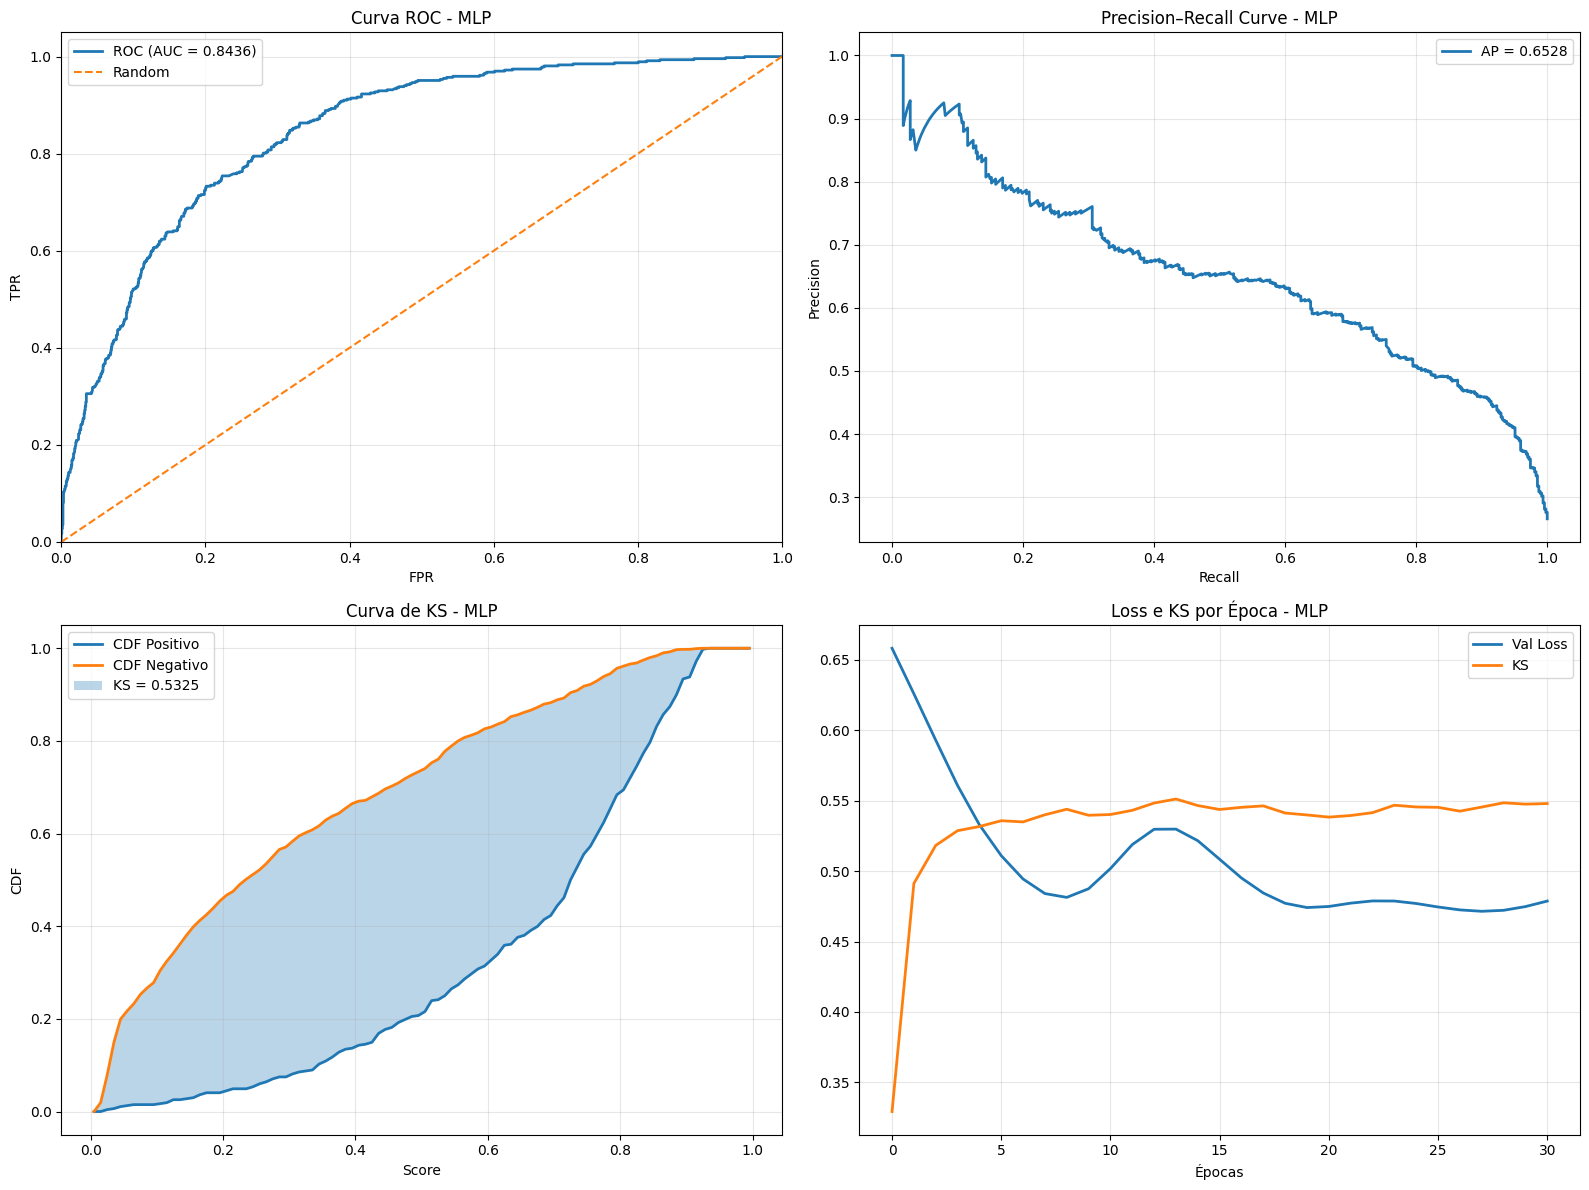

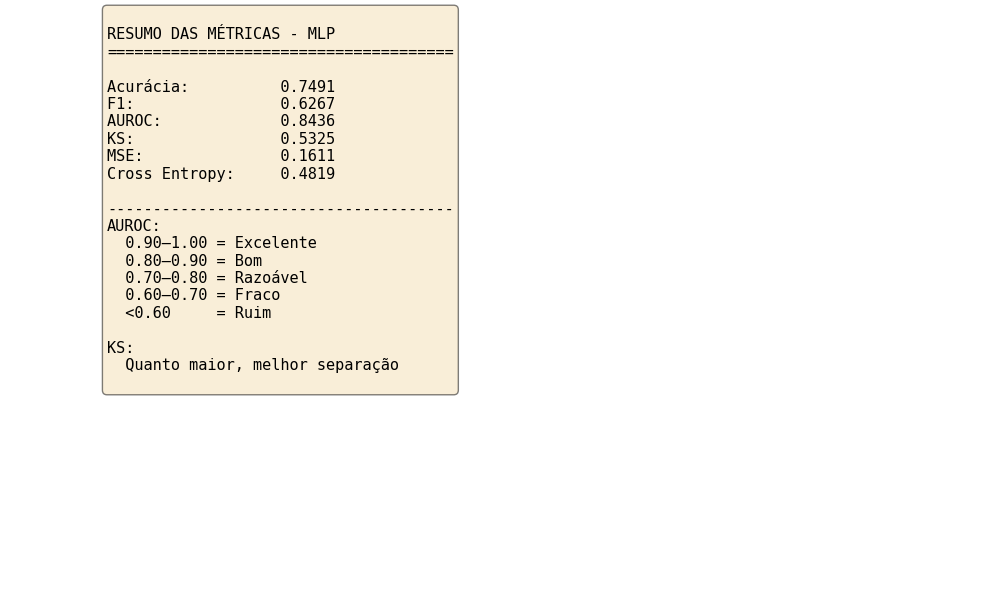

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, mean_squared_error, log_loss
import matplotlib.pyplot as plt

# ================================
#  MÉTRICAS BÁSICAS
# ================================
print("Acurácia:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("KS:", ks_statistic(y_test, y_prob))

# ================================
#  GRÁFICOS PRINCIPAIS
# ================================

plt.figure(figsize=(16,12))

# ---------------- ROC ----------------
ax_roc = plt.subplot(2,2,1)
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

ax_roc.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {auc:.4f})')
ax_roc.plot([0,1], [0,1], linestyle='--', label='Random')

ax_roc.set_xlim([0,1])
ax_roc.set_ylim([0,1.05])
ax_roc.set_xlabel("FPR")
ax_roc.set_ylabel("TPR")
ax_roc.set_title("Curva ROC - MLP")
ax_roc.legend()
ax_roc.grid(True, alpha=0.3)

# ------------- Precision–Recall -------------
ax_pr = plt.subplot(2,2,2)

prec, rec, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

ax_pr.plot(rec, prec, lw=2, label=f"AP = {ap:.4f}")
ax_pr.set_title("Precision–Recall Curve - MLP")
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.legend()
ax_pr.grid(True, alpha=0.3)

# ---------------- KS Curve ----------------
ax_ks = plt.subplot(2,2,3)

y_prob_pos = y_prob[y_test == 1]
y_prob_neg = y_prob[y_test == 0]

bins = np.linspace(0,1,101)

pos_hist, _ = np.histogram(y_prob_pos, bins=bins, density=True)
neg_hist, _ = np.histogram(y_prob_neg, bins=bins, density=True)

cum_pos = np.cumsum(pos_hist) / np.sum(pos_hist)
cum_neg = np.cumsum(neg_hist) / np.sum(neg_hist)

bin_centers = (bins[:-1] + bins[1:]) / 2

ax_ks.plot(bin_centers, cum_pos, label="CDF Positivo", lw=2)
ax_ks.plot(bin_centers, cum_neg, label="CDF Negativo", lw=2)

ax_ks.fill_between(
    bin_centers, cum_pos, cum_neg, alpha=0.3,
    label=f"KS = {ks_statistic(y_test, y_prob):.4f}"
)

ax_ks.set_title("Curva de KS - MLP")
ax_ks.set_xlabel("Score")
ax_ks.set_ylabel("CDF")
ax_ks.legend()
ax_ks.grid(True, alpha=0.3)

# ----------- LOSS E KS por época -----------
ax_loss = plt.subplot(2,2,4)

ax_loss.plot(history["val_loss"], label="Val Loss", lw=2)
ax_loss.plot(history["val_ks"], label="KS", lw=2)

ax_loss.set_xlabel("Épocas")
ax_loss.set_title("Loss e KS por Época - MLP")
ax_loss.legend()
ax_loss.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================
#      TABELA FINAL
# =============================
mse_final = mean_squared_error(y_test, y_prob)
cross_entropy_final = log_loss(y_test, y_prob)

fig_metrics, ax_m = plt.subplots(1,1, figsize=(10,6))
ax_m.axis("off")

texto = f"""
RESUMO DAS MÉTRICAS - MLP
======================================

Acurácia:          {accuracy_score(y_test, y_pred):.4f}
F1:                {f1_score(y_test, y_pred):.4f}
AUROC:             {roc_auc_score(y_test, y_prob):.4f}
KS:                {ks_statistic(y_test, y_prob):.4f}
MSE:               {mse_final:.4f}
Cross Entropy:     {cross_entropy_final:.4f}

--------------------------------------
AUROC:
  0.90–1.00 = Excelente
  0.80–0.90 = Bom
  0.70–0.80 = Razoável
  0.60–0.70 = Fraco
  <0.60     = Ruim

KS:
  Quanto maior, melhor separação
"""

ax_m.text(0.1, 0.5, texto, fontsize=11, family="monospace",
          bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.show()

## Experimento com STab

### Import

In [ ]:
!pip install keras4torch
!pip install einops
!pip install optuna

import sys
import os

sys.path.append('/content/STab')

# 1. Criar o diretório STab
if not os.path.exists('/content/STab'):
    os.makedirs('/content/STab')
    print("Diretório '/content/STab' criado.")
else:
    print("Diretório '/content/STab' já existe.")

# 2. Baixar os arquivos .py do repositório STAB para a pasta /content/STab
# Se já tiver os arquivos, pode pular esta etapa ou remover os arquivos existentes antes de baixar novamente.
!wget -O /content/STab/mainmodel.py https://raw.githubusercontent.com/kailanefelix/stab-redes-neurais/main/STAB/mainmodel.py
!wget -O /content/STab/LWTA.py https://raw.githubusercontent.com/kailanefelix/stab-redes-neurais/main/STAB/LWTA.py
!wget -O /content/STab/Gsoftmax.py https://raw.githubusercontent.com/kailanefelix/stab-redes-neurais/main/STAB/Gsoftmax.py
!wget -O /content/STab/helper.py https://raw.githubusercontent.com/kailanefelix/stab-redes-neurais/main/STAB/helper.py
!wget -O /content/STab/model_wrapper.py https://raw.githubusercontent.com/kailanefelix/stab-redes-neurais/main/STAB/model_wrapper.py
!wget -O /content/STab/utils.py https://raw.githubusercontent.com/kailanefelix/stab-redes-neurais/main/STAB/utils.py
!wget -O /content/STab/__init__.py https://raw.githubusercontent.com/kailanefelix/stab-redes-neurais/main/STAB/__init__.py

print("Arquivos STab baixados para '/content/STab/'.")

# 3. Corrigir o arquivo __init__.py para usar importações relativas
init_py_path = '/content/STab/__init__.py'

with open(init_py_path, 'r') as f:
    content = f.read()

# Substituir 'from STab.' por 'from .' para importações relativas
content = content.replace('from STab.', 'from .')

with open(init_py_path, 'w') as f:
    f.write(content)

print("Arquivo __init__.py corrigido para usar importações relativas.")

import gc
from copy import deepcopy
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import mean_squared_error, log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, QuantileTransformer
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from scipy.stats import ks_2samp
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import keras4torch
from keras4torch.callbacks import ModelCheckpoint, LRScheduler, EarlyStopping
import STab
from STab import *
from STab import mainmodel, LWTA, Gsoftmax

import optuna
from optuna.samplers import TPESampler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 11.3 MB/s eta 0:00:00
Diretório '/content/STab' criado.
--2025-12-16 09:09:53--  https://raw.githubusercontent.com/kailanefelix/stab-redes-neurais/main/STAB/mainmodel.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9043 (8.8K) [text/plain]
Saving to: ‘/content/STab/mainmodel.py’

/content/STab/mainm 100%[===================>]   8.83K  --.-KB/s    in 0s      

2025-12-16 09:09:53 (98.4 MB/s) - ‘/content/STab/mainmodel.py’ saved [9043/9043]

--2025-12-16 09:09:53--  https://raw.githubusercontent.com/kailanefelix/stab-redes-neurais/main/STAB/LWTA.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercon

### Funções de Otimização e Objetivo (Optuna)

In [ ]:
class MetricsCalculator:
    @staticmethod
    def calculate_ks_auroc(y_true, y_probs):
        """Calcula KS e AUROC"""
        probs_class_0 = y_probs[y_true == 0]
        probs_class_1 = y_probs[y_true == 1]

        ks_statistic, _ = ks_2samp(probs_class_0, probs_class_1)
        auroc = roc_auc_score(y_true, y_probs)

        return ks_statistic, auroc

def objective(trial, X_train, y_train, X_valid, y_valid):
    """
    Função objetivo Optuna adaptada ao dataset de churn
    """

    # ======================
    # Hiperparâmetros
    # ======================
    dim = trial.suggest_categorical('dim', [8, 16, 32, 64, 128])
    depth = trial.suggest_int('depth', 1, 6)
    heads = trial.suggest_categorical('heads', [2, 4, 8])
    attn_dropout = trial.suggest_float('attn_dropout', 0.0, 0.3)
    ff_dropout = trial.suggest_float('ff_dropout', 0.0, 0.3)
    U = trial.suggest_categorical('U', [2, 4, 8, 16])
    cases = trial.suggest_categorical('cases', [2, 4, 8, 16])

    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128, 256])
    sample_size = trial.suggest_categorical('sample_size', [8, 16, 32, 64])

    num_features = X_train.shape[1]

    try:
        # ======================
        # Conversão para torch
        # ======================
        X_train_t = torch.tensor(X_train, dtype=torch.float32)
        X_valid_t = torch.tensor(X_valid, dtype=torch.float32)

        y_train_t = torch.tensor(
            y_train.values if hasattr(y_train, "values") else y_train,
            dtype=torch.long
        )
        y_valid_t = torch.tensor(
            y_valid.values if hasattr(y_valid, "values") else y_valid,
            dtype=torch.long
        )

        # ======================
        # Modelo STab
        # ======================
        base_model = mainmodel.MainModel(
            categories=(),
            num_continuous=num_features,
            dim=dim,
            dim_out=2,
            depth=depth,
            heads=heads,
            attn_dropout=attn_dropout,
            ff_dropout=ff_dropout,
            U=U,
            cases=cases
        )

        stab_model = Num_Cat(
            base_model,
            num_number=num_features,
            classes=2,
            Sample_size=sample_size
        )

        model = keras4torch.Model(stab_model).build([num_features])

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

        model.compile(
            optimizer=optimizer,
            loss=F.cross_entropy,
            metrics=['accuracy']
        )

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=5
        )

        # ======================
        # Treinamento
        # ======================
        history = model.fit(
            [X_train_t], y_train_t,
            epochs=30,
            batch_size=batch_size,
            validation_data=([X_valid_t], y_valid_t),
            callbacks=[early_stop],
            verbose=0
        )

        # ======================
        # Avaliação Validação
        # ======================
        valid_logits = model.predict([X_valid_t])
        valid_probs = F.softmax(
            torch.tensor(valid_logits), dim=1
        ).numpy()[:, 1]

        ks_statistic, auroc = MetricsCalculator.calculate_ks_auroc(
            y_valid_t.numpy(),
            valid_probs
        )

        # ======================
        # Limpeza de memória
        # ======================
        del model, optimizer, base_model, stab_model
        torch.cuda.empty_cache()
        gc.collect()

        trial.set_user_attr('ks', ks_statistic)
        trial.set_user_attr('auroc', auroc)
        trial.set_user_attr('epochs_trained', len(history['loss']))

        return ks_statistic, auroc

    except Exception as e:
        print(f"Trial {trial.number} falhou: {e}")
        return 0.0, 0.5

def optimize_stab_model(X_train, y_train, X_valid, y_valid,
                        n_trials=50, timeout=None):

    study = optuna.create_study(
        directions=['maximize', 'maximize'],
        sampler=TPESampler(seed=42),
        study_name='stab_optimization'
    )

    print("="*80)
    print("OTIMIZAÇÃO STAB - DATASET DE CHURN")
    print("="*80)
    print(f"Trials: {n_trials}")
    print("Objetivo primário: KS")
    print("Desempate: AUROC")
    print("="*80)

    study.optimize(
        lambda trial: objective(trial, X_train, y_train, X_valid, y_valid),
        n_trials=n_trials,
        timeout=timeout,
        show_progress_bar=True
    )

    return study

def display_optimization_results(study):

    print("\n" + "="*80)
    print("RESULTADOS DA OTIMIZAÇÃO")
    print("="*80)

    best_trials = study.best_trials

    if len(best_trials) > 0:
        best_trials_sorted = sorted(best_trials,
                                    key=lambda t: (t.values[0], t.values[1]),
                                    reverse=True)
        best_trial = best_trials_sorted[0]

        print(f"\nMelhor Trial (baseado em KS + AUROC):")
        print(f"  Trial número: {best_trial.number}")
        print(f"  KS Statistic: {best_trial.values[0]:.4f}")
        print(f"  AUROC: {best_trial.values[1]:.4f}")
        print(f"  Épocas treinadas: {best_trial.user_attrs.get('epochs_trained', 'N/A')}")

        print("\n" + "-"*80)
        print("Melhores Hiperparâmetros:")
        print("-"*80)
        for key, value in best_trial.params.items():
            print(f"  {key:20s}: {value}")
        print("-"*80)

        print("\n" + "="*80)
        print("TOP 5 TRIALS")
        print("="*80)

        results_data = []
        for i, trial in enumerate(best_trials_sorted[:5], 1):
            results_data.append({
                'Rank': i,
                'Trial': trial.number,
                'KS': f"{trial.values[0]:.4f}",
                'AUROC': f"{trial.values[1]:.4f}",
                'dim': trial.params.get('dim', 'N/A'),
                'depth': trial.params.get('depth', 'N/A'),
                'heads': trial.params.get('heads', 'N/A'),
                'U': trial.params.get('U', 'N/A'),
                'cases': trial.params.get('cases', 'N/A'),
                'lr': f"{trial.params.get('lr', 0):.2e}",
                'batch_size': trial.params.get('batch_size', 'N/A')
            })

        df_results = pd.DataFrame(results_data)
        print(df_results.to_string(index=False))
        print("="*80)

        return best_trial
    else:
        print("Nenhum trial completado com sucesso!")
        return None

### Função de Treino

In [ ]:
def train_final_model(best_params,
                      X_train, y_train,
                      X_valid, y_valid,
                      X_test, y_test):

    print("\n" + "="*80)
    print("TREINANDO MODELO FINAL STab")
    print("="*80)

    # ======================
    # Hiperparâmetros
    # ======================
    dim = best_params['dim']
    depth = best_params['depth']
    heads = best_params['heads']
    attn_dropout = best_params['attn_dropout']
    ff_dropout = best_params['ff_dropout']
    U = best_params['U']
    cases = best_params['cases']
    lr = best_params['lr']
    weight_decay = best_params['weight_decay']
    batch_size = best_params['batch_size']
    sample_size = best_params['sample_size']

    num_features = X_train.shape[1]

    # ======================
    # Conversão para torch
    # ======================
    X_train = torch.tensor(X_train, dtype=torch.float32)
    X_valid = torch.tensor(X_valid, dtype=torch.float32)
    X_test  = torch.tensor(X_test,  dtype=torch.float32)

    y_train = torch.tensor(y_train.values if hasattr(y_train, "values") else y_train,
                           dtype=torch.long)
    y_valid = torch.tensor(y_valid.values if hasattr(y_valid, "values") else y_valid,
                           dtype=torch.long)
    y_test  = torch.tensor(y_test.values  if hasattr(y_test,  "values") else y_test,
                           dtype=torch.long)

    # ======================
    # Modelo STab
    # ======================
    base_model = mainmodel.MainModel(
        categories=(),              # SEM categóricas
        num_continuous=num_features,
        dim=dim,
        dim_out=2,
        depth=depth,
        heads=heads,
        attn_dropout=attn_dropout,
        ff_dropout=ff_dropout,
        U=U,
        cases=cases
    )

    stab_model = Num_Cat(
        base_model,
        num_number=num_features,
        classes=2,
        Sample_size=sample_size
    )

    model = keras4torch.Model(stab_model).build([num_features])

    # ======================
    # Otimizador e loss
    # ======================
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    model.compile(
        optimizer=optimizer,
        loss=F.cross_entropy,
        metrics=['accuracy']
    )

    # ======================
    # Callbacks
    # ======================
    early_stop = EarlyStopping(
      monitor='val_loss',
      patience=10
    )

    # ======================
    # Treinamento
    # ======================
    history = model.fit(
        [X_train], y_train,
        epochs=50,
        batch_size=batch_size,
        validation_data=([X_valid], y_valid),
        callbacks=[early_stop],
        verbose=2
    )

    # ======================
    # Avaliação
    # ======================
    print("\n" + "="*80)
    print("AVALIAÇÃO NO CONJUNTO DE TESTE")
    print("="*80)

    test_logits = model.predict([X_test])
    test_preds = np.argmax(test_logits, axis=1)

    test_probs = F.softmax(
        torch.tensor(test_logits), dim=1
    ).numpy()[:, 1]

    test_accuracy = (test_preds == y_test.numpy()).mean()

    ks_statistic, auroc = MetricsCalculator.calculate_ks_auroc(
        y_test.numpy(),
        test_probs
    )

    print(f"Accuracy: {test_accuracy:.4f}")
    print(f"KS:       {ks_statistic:.4f}")
    print(f"AUROC:    {auroc:.4f}")

    print("\nRelatório de Classificação:")
    print(classification_report(
        y_test.numpy(),
        test_preds,
        target_names=['Não Churn', 'Churn'],
        digits=4
    ))

    metrics = {
        'accuracy': test_accuracy,
        'ks': ks_statistic,
        'auroc': auroc,
        'y_true': y_test.numpy(),
        'y_pred': test_preds,
        'y_prob': test_probs
    }

    return model, history, metrics

### Preparação dos dados para Optuna

In [ ]:
print("\n" + "="*80)
print("PREPARAÇÃO DOS DADOS - STAB")
print("="*80)

# ======================
# Dados já escalados
# ======================
X_train_STab = X_train_scaled
y_train_STab = y_train_bal

X_valid_STab = X_val_scaled
y_valid_STab = y_val

X_test_STab  = X_test_scaled
y_test_STab  = y_test

# ======================
# Garantir tipos corretos
# ======================
X_train_STab = X_train_STab.astype(np.float32)
X_valid_STab = X_valid_STab.astype(np.float32)
X_test_STab  = X_test_STab.astype(np.float32)

# y permanece numpy / pandas (torch será feito dentro das funções)
y_train_STab = y_train_STab.values if hasattr(y_train_STab, "values") else y_train_STab
y_valid_STab = y_valid_STab.values if hasattr(y_valid_STab, "values") else y_valid_STab
y_test_STab  = y_test_STab.values  if hasattr(y_test_STab,  "values") else y_test_STab

num_features = X_train_STab.shape[1]

print(f"Número de features: {num_features}")
print(f"Tamanho treino (balanceado): {len(y_train_STab)}")
print(f"Tamanho validação: {len(y_valid_STab)}")
print(f"Tamanho teste: {len(y_test_STab)}")


PREPARAÇÃO DOS DADOS - STAB
Número de features: 30
Tamanho treino (balanceado): 5174
Tamanho validação: 1760
Tamanho teste: 1762


### Otimização com Optuna

In [ ]:
N_TRIALS = 20
TIMEOUT = None

study = optimize_stab_model(
    X_train_STab, y_train_STab,
    X_valid_STab, y_valid_STab,
    n_trials=N_TRIALS,
    timeout=TIMEOUT
)

best_trial = display_optimization_results(study)


[I 2025-12-16 09:10:00,731] A new study created in memory with name: stab_optimization


OTIMIZAÇÃO STAB - DATASET DE CHURN
Trials: 20
Objetivo primário: KS
Desempate: AUROC


  0%|          | 0/20 [00:00<?, ?it/s]

[INFO] Early Stopped. The best score is 0.4787.
[I 2025-12-16 09:10:53,175] Trial 0 finished with values: [0.5527655916970146, 0.8523295425375644] and parameters: {'dim': 16, 'depth': 1, 'heads': 4, 'attn_dropout': 0.21242177333881365, 'ff_dropout': 0.006175348288740734, 'U': 2, 'cases': 8, 'lr': 0.0003823475224675188, 'weight_decay': 6.847920095574779e-05, 'batch_size': 256, 'sample_size': 8}.
[INFO] Early Stopped. The best score is 0.4249.
[I 2025-12-16 09:20:05,712] Trial 1 finished with values: [0.5460567609148917, 0.8528495555875735] and parameters: {'dim': 128, 'depth': 6, 'heads': 2, 'attn_dropout': 0.20526990795364705, 'ff_dropout': 0.13204574812188039, 'U': 16, 'cases': 4, 'lr': 0.0012399967836846098, 'weight_decay': 3.5856126103453987e-06, 'batch_size': 32, 'sample_size': 16}.
[INFO] Early Stopped. The best score is 0.4706.
[I 2025-12-16 09:22:36,787] Trial 2 finished with values: [0.5540805291546806, 0.8571255864637621] and parameters: {'dim': 128, 'depth': 3, 'heads': 4, 'a

### Treinamento do modelo otimizado

In [ ]:
if best_trial is not None:

    model_final, history_final, test_metrics_final = train_final_model(
        best_params=best_trial.params,
        X_train=X_train_STab,
        y_train=y_train_STab,
        X_valid=X_valid_STab,
        y_valid=y_valid_STab,
        X_test=X_test_STab,
        y_test=y_test_STab
    )


TREINANDO MODELO FINAL STab
Train on 5174 samples, validate on 1760 samples:
Epoch 1/50 - 42s - loss: 0.5854 - acc: 0.6939 - val_loss: 0.4796 - val_acc: 0.7705 - lr: 1.2e-03
Epoch 2/50 - 25s - loss: 0.5328 - acc: 0.7362 - val_loss: 0.4754 - val_acc: 0.7591 - lr: 1.2e-03
Epoch 3/50 - 25s - loss: 0.5215 - acc: 0.7404 - val_loss: 0.4625 - val_acc: 0.7744 - lr: 1.2e-03
Epoch 4/50 - 25s - loss: 0.5156 - acc: 0.7439 - val_loss: 0.4575 - val_acc: 0.7812 - lr: 1.2e-03
Epoch 5/50 - 25s - loss: 0.5074 - acc: 0.7522 - val_loss: 0.4632 - val_acc: 0.7739 - lr: 1.2e-03
Epoch 6/50 - 25s - loss: 0.5114 - acc: 0.7420 - val_loss: 0.4590 - val_acc: 0.7784 - lr: 1.2e-03
Epoch 7/50 - 27s - loss: 0.5013 - acc: 0.7505 - val_loss: 0.4949 - val_acc: 0.7540 - lr: 1.2e-03
Epoch 8/50 - 25s - loss: 0.5039 - acc: 0.7462 - val_loss: 0.5240 - val_acc: 0.7239 - lr: 1.2e-03
Epoch 9/50 - 26s - loss: 0.5042 - acc: 0.7470 - val_loss: 0.4315 - val_acc: 0.7943 - lr: 1.2e-03
Epoch 10/50 - 25s - loss: 0.4999 - acc: 0.7559 - 

### Gráficos

Acurácia: 0.7797956867196367
F1: 0.6360225140712945
AUC: 0.8431749428658237
KS: 0.5382567801424061


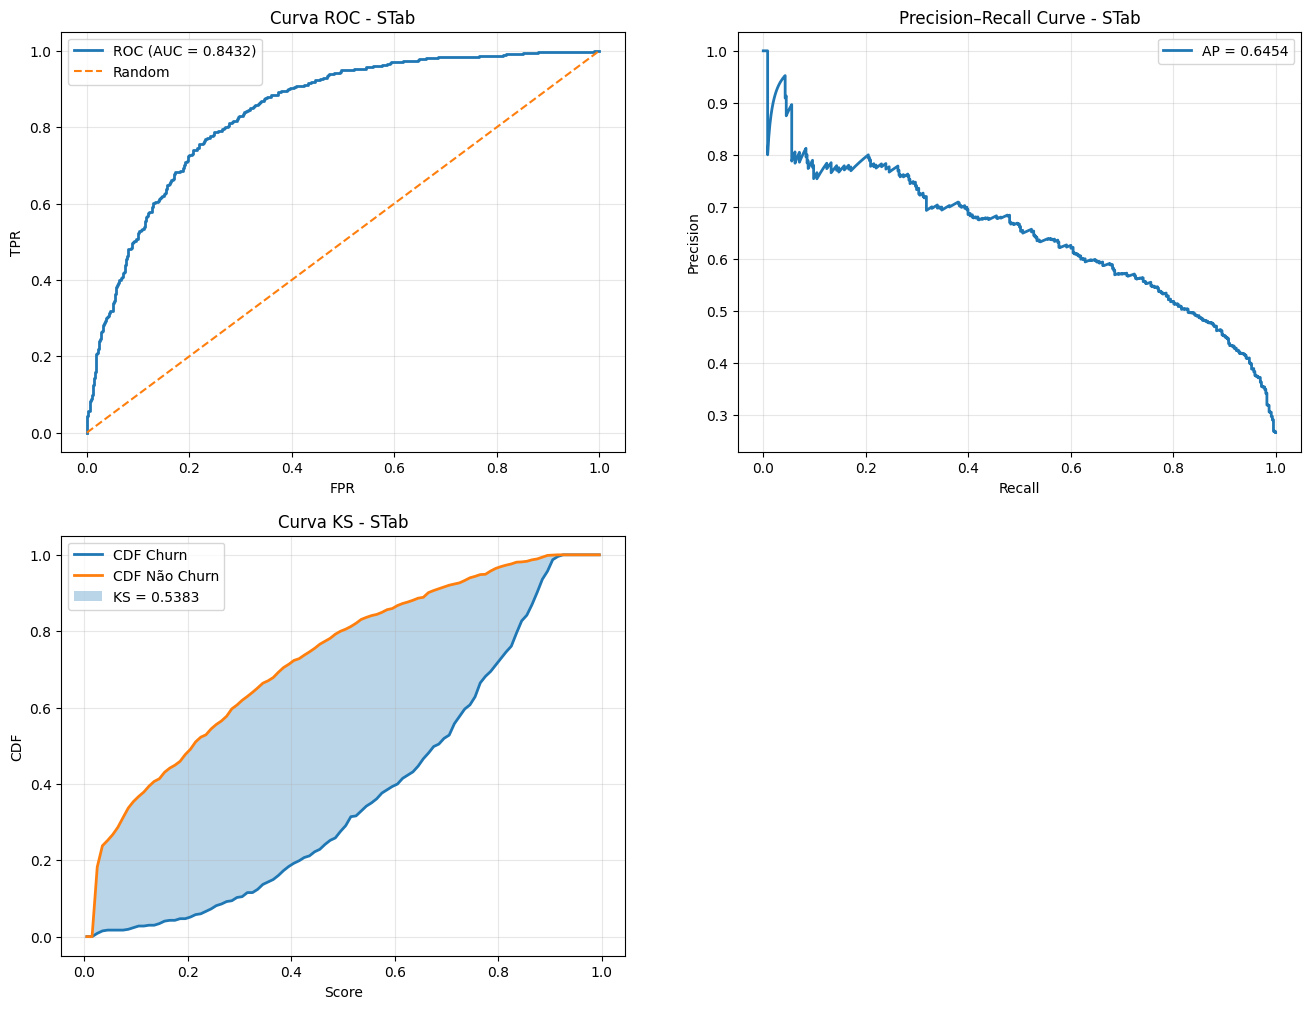

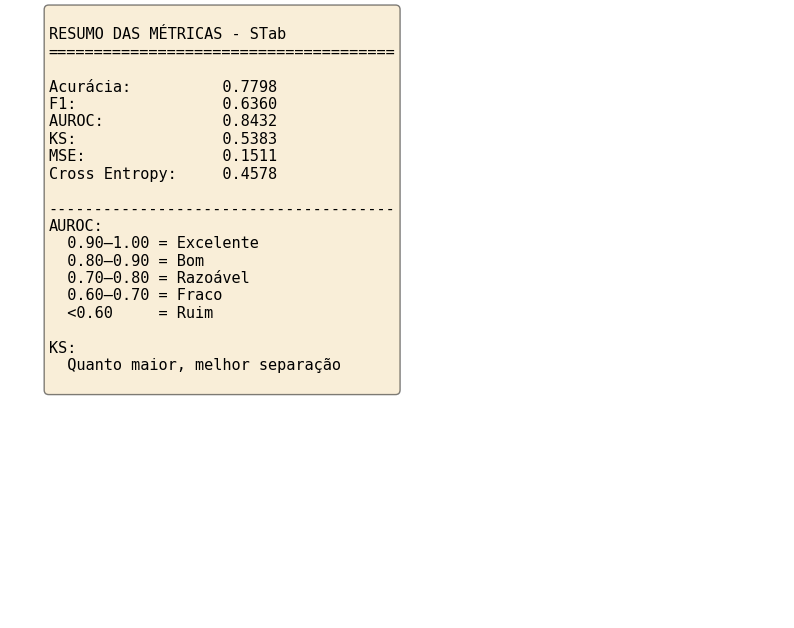

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, mean_squared_error, log_loss
import matplotlib.pyplot as plt

# ================================
#  MÉTRICAS BÁSICAS
# ================================
y_test = test_metrics_final['y_true']
y_pred = test_metrics_final['y_pred']
y_prob = test_metrics_final['y_prob']

print("Acurácia:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("KS:", test_metrics_final['ks'])

# ================================
#  GRÁFICOS PRINCIPAIS
# ================================

plt.figure(figsize=(16,12))

# ---------------- ROC ----------------
ax_roc = plt.subplot(2, 2, 1)

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

ax_roc.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {auc:.4f})')
ax_roc.plot([0, 1], [0, 1], linestyle='--', label='Random')

ax_roc.set_xlabel("FPR")
ax_roc.set_ylabel("TPR")
ax_roc.set_title("Curva ROC - STab")
ax_roc.legend()
ax_roc.grid(True, alpha=0.3)

# ------------- Precision–Recall -------------
ax_pr = plt.subplot(2, 2, 2)

prec, rec, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

ax_pr.plot(rec, prec, lw=2, label=f"AP = {ap:.4f}")
ax_pr.set_title("Precision–Recall Curve - STab")
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.legend()
ax_pr.grid(True, alpha=0.3)

# ---------------- KS Curve ----------------
ax_ks = plt.subplot(2, 2, 3)

y_prob_pos = y_prob[y_test == 1]
y_prob_neg = y_prob[y_test == 0]

bins = np.linspace(0, 1, 101)

pos_hist, _ = np.histogram(y_prob_pos, bins=bins, density=True)
neg_hist, _ = np.histogram(y_prob_neg, bins=bins, density=True)

cum_pos = np.cumsum(pos_hist) / np.sum(pos_hist)
cum_neg = np.cumsum(neg_hist) / np.sum(neg_hist)

bin_centers = (bins[:-1] + bins[1:]) / 2

ax_ks.plot(bin_centers, cum_pos, label="CDF Churn", lw=2)
ax_ks.plot(bin_centers, cum_neg, label="CDF Não Churn", lw=2)

ax_ks.fill_between(
    bin_centers, cum_pos, cum_neg, alpha=0.3,
    label=f"KS = {test_metrics_final['ks']:.4f}"
)

ax_ks.set_title("Curva KS - STab")
ax_ks.set_xlabel("Score")
ax_ks.set_ylabel("CDF")
ax_ks.legend()
ax_ks.grid(True, alpha=0.3)

# =============================
#      TABELA FINAL
# =============================
mse_final = mean_squared_error(y_test, y_prob)
cross_entropy_final = log_loss(y_test, y_prob)

fig_metrics, ax_m = plt.subplots(figsize=(10, 6))
ax_m.axis("off")

texto = f"""
RESUMO DAS MÉTRICAS - STab
======================================

Acurácia:          {accuracy_score(y_test, y_pred):.4f}
F1:                {f1_score(y_test, y_pred):.4f}
AUROC:             {roc_auc_score(y_test, y_prob):.4f}
KS:                {test_metrics_final['ks']:.4f}
MSE:               {mse_final:.4f}
Cross Entropy:     {cross_entropy_final:.4f}

--------------------------------------
AUROC:
  0.90–1.00 = Excelente
  0.80–0.90 = Bom
  0.70–0.80 = Razoável
  0.60–0.70 = Fraco
  <0.60     = Ruim

KS:
  Quanto maior, melhor separação
"""

ax_m.text(
    0.05, 0.5, texto,
    fontsize=11,
    family="monospace",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5)
)

plt.show()

## Experimento com KAN

### Imports

In [ ]:
# ============================
# 1. Optuna
# ============================
try:
    import optuna
    print("Optuna já instalado.")
except ImportError:
    print("Instalando Optuna...")
    !pip install optuna
    import optuna

# ============================
# 2. pykan (KAN)
# ============================
try:
    from kan import KAN
    print("pykan já instalado.")
except ImportError:
    print("Instalando pykan do GitHub...")
    !pip install git+https://github.com/KindXiaoming/pykan.git
    from kan import KAN

# ============================
# 3. Imports padrão
# ============================
import torch
import torch.nn as nn
import pandas as pd
import numpy as np

# ============================
# 4. Device
# ============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Optuna já instalado.
pykan já instalado.
Device: cuda


### Preparação dos dados

In [ ]:
X_train = X_train_scaled.astype(np.float32)
y_train = y_train_bal.values if hasattr(y_train_bal, "values") else y_train_bal

X_val = X_val_scaled.astype(np.float32)
y_val = y_val.values if hasattr(y_val, "values") else y_val

X_test = X_test_scaled.astype(np.float32)
y_test = y_test.values if hasattr(y_test, "values") else y_test

# ============================
# Dimensão de entrada
# ============================
input_dim = X_train.shape[1]

print("Dimensão das features:", input_dim)
print("Tamanho treino:", X_train.shape[0])
print("Tamanho validação:", X_val.shape[0])
print("Tamanho teste:", X_test.shape[0])

Dimensão das features: 30
Tamanho treino: 5174
Tamanho validação: 1760
Tamanho teste: 1762


### Funções auxiliares e Função treino

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report
)
from scipy.stats import ks_2samp
import numpy as np

def ks_statistic(y_true, y_prob):
    prob_pos = y_prob[y_true == 1]
    prob_neg = y_prob[y_true == 0]
    ks, _ = ks_2samp(prob_pos, prob_neg)
    return ks

def objective(trial):

    # ============================
    # Hiperparâmetros
    # ============================
    hidden1 = trial.suggest_int("hidden1", 8, 64)
    hidden2 = trial.suggest_int("hidden2", 8, 32)
    grid = trial.suggest_int("grid", 3, 8)
    k = trial.suggest_int("k", 2, 4)
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    epochs = trial.suggest_int("epochs", 30, 80)

    # ============================
    # Modelo KAN
    # ============================
    model = KAN(
        width=[X_train.shape[1], hidden1, hidden2, 1],
        grid=grid,
        k=k,
        seed=42,
        device=device
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    loss_fn = nn.BCEWithLogitsLoss()

    # ============================
    # Tensores
    # ============================
    Xtr = torch.tensor(X_train, dtype=torch.float32).to(device)
    ytr = torch.tensor(y_train, dtype=torch.float32).to(device)

    Xva = torch.tensor(X_val, dtype=torch.float32).to(device)
    yva = torch.tensor(y_val, dtype=torch.float32).to(device)

    # ============================
    # Treinamento
    # ============================
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        logits = model(Xtr).squeeze()
        loss = loss_fn(logits, ytr)
        loss.backward()
        optimizer.step()

    # ============================
    # Avaliação (VALIDAÇÃO)
    # ============================
    model.eval()
    with torch.no_grad():
        val_logits = model(Xva).squeeze()
        val_probs = torch.sigmoid(val_logits).cpu().numpy()

    # ============================
    # MÉTRICAS
    # ============================
    ks = ks_statistic(y_val, val_probs)
    auroc = roc_auc_score(y_val, val_probs)

    # Guardar métricas extras
    trial.set_user_attr("auroc", auroc)

    return ks

def train_final_kan(best_params, X_train, y_train, X_test, y_test, device):

    print("\n" + "="*80)
    print("TREINAMENTO FINAL - KAN")
    print("="*80)

    # ============================
    # Hiperparâmetros
    # ============================
    hidden1 = best_params["hidden1"]
    hidden2 = best_params["hidden2"]
    grid = best_params["grid"]
    k = best_params["k"]
    lr = best_params["lr"]
    weight_decay = best_params["weight_decay"]
    epochs = best_params["epochs"]

    input_dim = X_train.shape[1]

    # ============================
    # Modelo
    # ============================
    model = KAN(
        width=[input_dim, hidden1, hidden2, 1],
        grid=grid,
        k=k,
        seed=42,
        device=device
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    loss_fn = nn.BCEWithLogitsLoss()

    # ============================
    # Tensores
    # ============================
    Xtr = torch.tensor(X_train, dtype=torch.float32).to(device)
    ytr = torch.tensor(y_train, dtype=torch.float32).to(device)

    Xte = torch.tensor(X_test, dtype=torch.float32).to(device)
    yte = torch.tensor(y_test, dtype=torch.float32).to(device)

    # ============================
    # Treinamento
    # ============================
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        logits = model(Xtr).squeeze()
        loss = loss_fn(logits, ytr)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f}")

    # ============================
    # Avaliação TESTE
    # ============================
    model.eval()
    with torch.no_grad():
        test_logits = model(Xte).squeeze()
        test_probs = torch.sigmoid(test_logits).cpu().numpy()
        test_preds = (test_probs >= 0.5).astype(int)

    # ============================
    # Métricas
    # ============================
    ks = ks_statistic(y_test, test_probs)
    auroc = roc_auc_score(y_test, test_probs)
    acc = accuracy_score(y_test, test_preds)
    f1 = f1_score(y_test, test_preds)

    print("\n" + "="*80)
    print("RESULTADOS NO TESTE")
    print("="*80)
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"KS:       {ks:.4f}")
    print(f"AUROC:    {auroc:.4f}")

    print("\nRelatório de Classificação:")
    print(classification_report(
        y_test,
        test_preds,
        target_names=["Não Churn", "Churn"],
        digits=4
    ))

    metrics = {
        "accuracy": acc,
        "f1": f1,
        "ks": ks,
        "auroc": auroc,
        "y_true": y_test,
        "y_pred": test_preds,
        "y_prob": test_probs
    }

    return model, metrics

### Estudo Optuna

In [ ]:
study = optuna.create_study(
    direction="maximize",   # KS ↑
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(
    objective,
    n_trials=20,
    show_progress_bar=True
)

best_trial = study.best_trial

print("Melhor KS:", best_trial.value)
print("AUROC correspondente:", best_trial.user_attrs["auroc"])

print("\nMelhores hiperparâmetros:")
for k, v in best_trial.params.items():
    print(f"{k}: {v}")

[I 2025-12-14 00:46:10,983] A new study created in memory with name: no-name-f3695eb1-47f3-416a-8392-6304c6b264e1


  0%|          | 0/20 [00:00<?, ?it/s]

checkpoint directory created: ./model
saving model version 0.0
[I 2025-12-14 00:47:06,072] Trial 0 finished with value: 0.42783328447860414 and parameters: {'hidden1': 29, 'hidden2': 31, 'grid': 7, 'k': 3, 'lr': 0.00018410729205738696, 'weight_decay': 2.9375384576328313e-06, 'epochs': 32}. Best is trial 0 with value: 0.42783328447860414.
checkpoint directory created: ./model
saving model version 0.0
[I 2025-12-14 00:49:35,127] Trial 1 finished with value: 0.5596781218585996 and parameters: {'hidden1': 57, 'hidden2': 23, 'grid': 7, 'k': 2, 'lr': 0.0044447541666908135, 'weight_decay': 0.0003142880890840109, 'epochs': 40}. Best is trial 1 with value: 0.5596781218585996.
checkpoint directory created: ./model
saving model version 0.0
[I 2025-12-14 00:50:28,654] Trial 2 finished with value: 0.5269587020209296 and parameters: {'hidden1': 18, 'hidden2': 12, 'grid': 4, 'k': 3, 'lr': 0.0005418282319533242, 'weight_decay': 7.4763120622522945e-06, 'epochs': 61}. Best is trial 1 with value: 0.55967

### Treino com modelo final e Gráficos

In [ ]:
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve,
    average_precision_score, mean_squared_error, log_loss
)
import matplotlib.pyplot as plt

model_kan_final, metrics_kan_final = train_final_kan(
    best_params=best_trial.params,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    device=device
)

y_true = metrics_kan_final["y_true"]
y_pred = metrics_kan_final["y_pred"]
y_prob = metrics_kan_final["y_prob"]

print("Acurácia:", accuracy_score(y_true, y_pred))
print("F1:", f1_score(y_true, y_pred))
print("AUROC:", roc_auc_score(y_true, y_prob))
print("KS:", ks_statistic(y_true, y_prob))


TREINAMENTO FINAL - KAN
checkpoint directory created: ./model
saving model version 0.0
Epoch 10/37 | Loss: 0.5471
Epoch 20/37 | Loss: 0.5137
Epoch 30/37 | Loss: 0.4860

RESULTADOS NO TESTE
Accuracy: 0.7565
F1-score: 0.6234
KS:       0.5400
AUROC:    0.8395

Relatório de Classificação:
              precision    recall  f1-score   support

   Não Churn     0.8964    0.7558    0.8201      1294
       Churn     0.5291    0.7585    0.6234       468

    accuracy                         0.7565      1762
   macro avg     0.7127    0.7572    0.7217      1762
weighted avg     0.7989    0.7565    0.7679      1762

Acurácia: 0.7565266742338252
F1: 0.6233538191395961
AUROC: 0.8395115853577988
KS: 0.5399906207479623


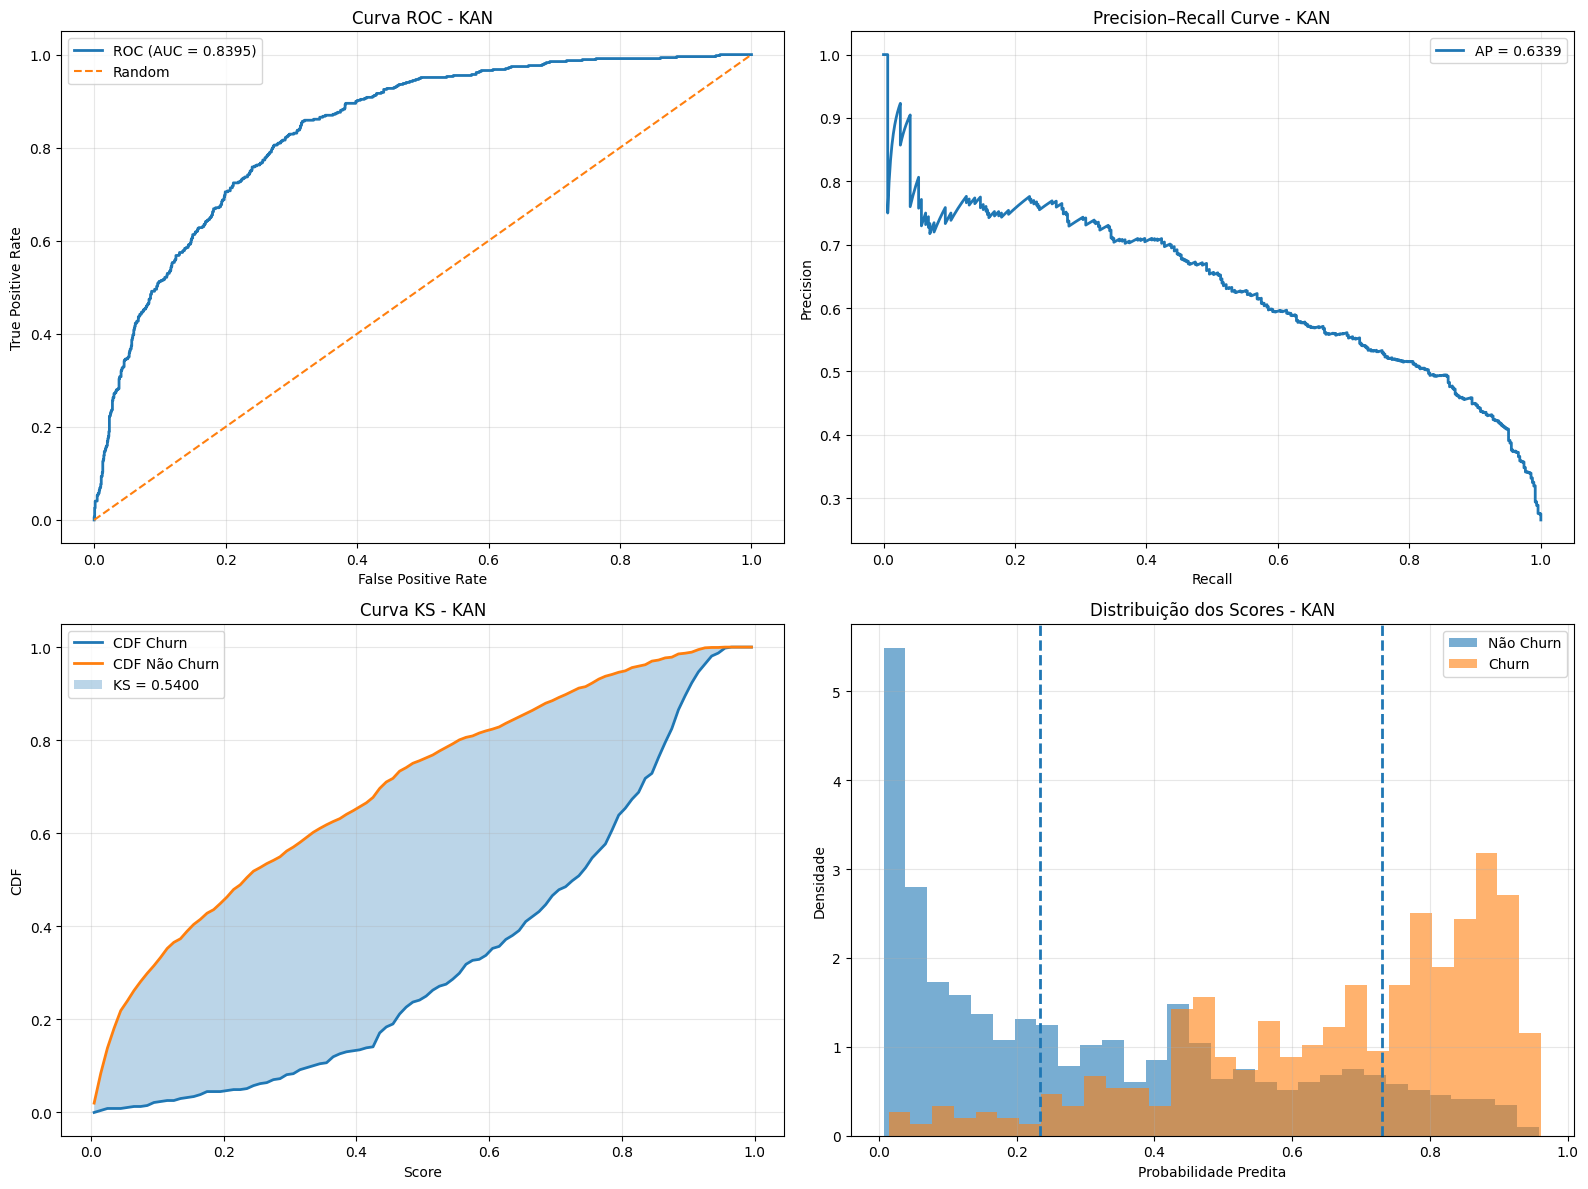

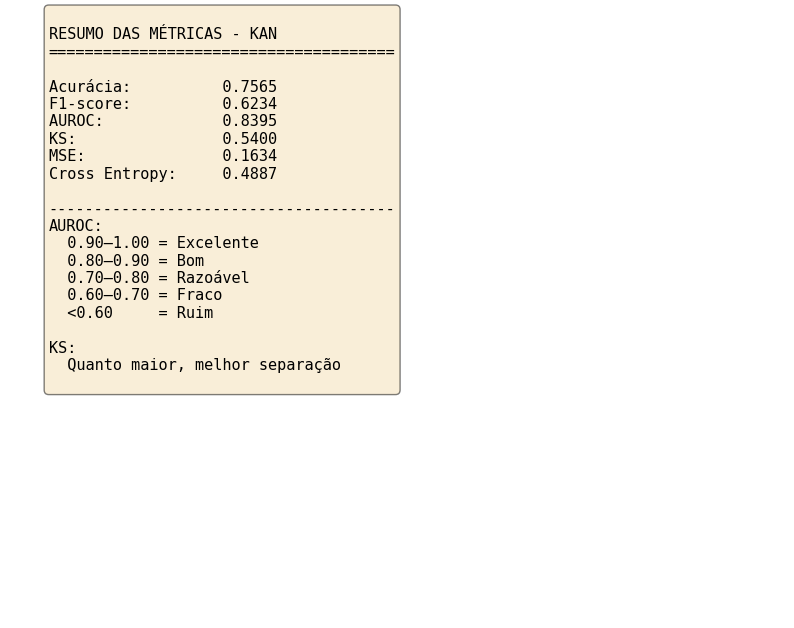

In [ ]:
plt.figure(figsize=(16, 12))

# ================= ROC =================
ax_roc = plt.subplot(2, 2, 1)

fpr, tpr, _ = roc_curve(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)

ax_roc.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {auc:.4f})')
ax_roc.plot([0, 1], [0, 1], linestyle='--', label='Random')

ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("Curva ROC - KAN")
ax_roc.legend()
ax_roc.grid(True, alpha=0.3)

# ============ Precision–Recall ============
ax_pr = plt.subplot(2, 2, 2)

precision, recall, _ = precision_recall_curve(y_true, y_prob)
ap = average_precision_score(y_true, y_prob)

ax_pr.plot(recall, precision, lw=2, label=f"AP = {ap:.4f}")
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision–Recall Curve - KAN")
ax_pr.legend()
ax_pr.grid(True, alpha=0.3)

# ================= KS =================
ax_ks = plt.subplot(2, 2, 3)

y_prob_pos = y_prob[y_true == 1]
y_prob_neg = y_prob[y_true == 0]

bins = np.linspace(0, 1, 101)

pos_hist, _ = np.histogram(y_prob_pos, bins=bins, density=True)
neg_hist, _ = np.histogram(y_prob_neg, bins=bins, density=True)

cum_pos = np.cumsum(pos_hist) / np.sum(pos_hist)
cum_neg = np.cumsum(neg_hist) / np.sum(neg_hist)

bin_centers = (bins[:-1] + bins[1:]) / 2

ax_ks.plot(bin_centers, cum_pos, label="CDF Churn", lw=2)
ax_ks.plot(bin_centers, cum_neg, label="CDF Não Churn", lw=2)

ks_value = ks_statistic(y_true, y_prob)

ax_ks.fill_between(
    bin_centers, cum_pos, cum_neg,
    alpha=0.3, label=f"KS = {ks_value:.4f}"
)

ax_ks.set_xlabel("Score")
ax_ks.set_ylabel("CDF")
ax_ks.set_title("Curva KS - KAN")
ax_ks.legend()
ax_ks.grid(True, alpha=0.3)

# ============ Distribuição Scores ============
ax_dist = plt.subplot(2, 2, 4)

ax_dist.hist(y_prob_neg, bins=30, alpha=0.6, density=True, label="Não Churn")
ax_dist.hist(y_prob_pos, bins=30, alpha=0.6, density=True, label="Churn")

ax_dist.axvline(np.median(y_prob_neg), linestyle="--", lw=2)
ax_dist.axvline(np.median(y_prob_pos), linestyle="--", lw=2)

ax_dist.set_xlabel("Probabilidade Predita")
ax_dist.set_ylabel("Densidade")
ax_dist.set_title("Distribuição dos Scores - KAN")
ax_dist.legend()
ax_dist.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

mse_final = mean_squared_error(y_true, y_prob)
cross_entropy_final = log_loss(y_true, y_prob)

fig, ax = plt.subplots(figsize=(10, 6))
ax.axis("off")

texto = f"""
RESUMO DAS MÉTRICAS - KAN
======================================

Acurácia:          {accuracy_score(y_true, y_pred):.4f}
F1-score:          {f1_score(y_true, y_pred):.4f}
AUROC:             {roc_auc_score(y_true, y_prob):.4f}
KS:                {ks_value:.4f}
MSE:               {mse_final:.4f}
Cross Entropy:     {cross_entropy_final:.4f}

--------------------------------------
AUROC:
  0.90–1.00 = Excelente
  0.80–0.90 = Bom
  0.70–0.80 = Razoável
  0.60–0.70 = Fraco
  <0.60     = Ruim

KS:
  Quanto maior, melhor separação
"""

ax.text(
    0.05, 0.5, texto,
    fontsize=11,
    family="monospace",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5)
)

plt.show()


## TabKANet

### Imports

In [ ]:
!pip install -q optuna

import sys
import os

sys.path.append('/content/TabKANet')

if not os.path.exists('/content/TabKANet'):
    !git clone https://github.com/AI-thpremed/TabKANet.git
    %cd TabKANet
    print("Diretório '/content/TabKANet' criado.")
else:
    print("Diretório '/content/TabKANet' já existe.")
    %cd TabKANet

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix
from scipy.stats import ks_2samp
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from tabkanet.models import TabKANet
import optuna

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 17.3 MB/s eta 0:00:00
Cloning into 'TabKANet'...
remote: Enumerating objects: 159, done.
remote: Counting objects: 100% (159/159), done.
remote: Compressing objects: 100% (103/103), done.
remote: Total 159 (delta 68), reused 125 (delta 47), pack-reused 0 (from 0)
Receiving objects: 100% (159/159), 9.61 MiB | 20.60 MiB/s, done.
Resolving deltas: 100% (68/68), done.
/content/TabKANet
Diretório '/content/TabKANet' criado.
Using cuda


### Funções auxiliares e função treino

In [ ]:
def ks_statistic(y_true, y_prob):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    pos = y_prob[y_true == 1]
    neg = y_prob[y_true == 0]

    return ks_2samp(pos, neg).statistic

def create_loader_numeric_only(x, y, batch_size=256, shuffle=True):
    dataset = TensorDataset(
        torch.zeros(len(x), 0, dtype=torch.long),
        torch.tensor(x.values, dtype=torch.float32),
        torch.tensor(y.values, dtype=torch.long)
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

def get_bins_all_continuous(x_cont, n_bins=4):
    x_np = np.asarray(x_cont, dtype=np.float32)

    bins = torch.zeros(x_np.shape[1], n_bins + 1)

    for i in range(x_np.shape[1]):
        qs = np.percentile(x_np[:, i], np.linspace(0, 100, n_bins + 1))
        qs = np.unique(qs)

        bins[i, :len(qs)] = torch.tensor(qs)
        if len(qs) < n_bins + 1:
            bins[i, len(qs):] = qs[-1]

    return bins

def create_tabkanet_numeric_model(num_cont_features, bins):
    return TabKANet(
    output_dim=2,
    vocabulary={},                      # vazio
    num_continuous_features=X_train.shape[1],
    embedding_dim=16,
    nhead=4,
    num_layers=2,
    dim_feedforward=64,
    attn_dropout_rate=0.2,
    mlp_hidden_dims=[32, 16],
    activation="gelu",
    ffn_dropout_rate=0.2,
    learninable_noise=True,
    bins=bins
).to(device)


def train_eval_tabkanet_ks(
    X_train, y_train,
    X_val, y_val,
    epochs=15,
    batch_size=256
):
    train_loader = create_loader_numeric_only(X_train, y_train, batch_size)
    val_loader = create_loader_numeric_only(X_val, y_val, batch_size=1024, shuffle=False)

    bins = get_bins_all_continuous(X_train.values)
    model = create_tabkanet_numeric_model(X_train.shape[1], bins)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    for _ in range(epochs):
        model.train()
        for cat, cont, y in train_loader:
            cat, cont, y = cat.to(device), cont.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(cat, cont)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

    # ===== KS =====
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for cat, cont, y in val_loader:
            cat, cont = cat.to(device), cont.to(device)
            p = torch.softmax(model(cat, cont), dim=1)[:, 1]
            probs.extend(p.cpu().numpy())
            labels.extend(y.numpy())

    ks = ks_2samp(
        np.array(probs)[np.array(labels) == 0],
        np.array(probs)[np.array(labels) == 1]
    ).statistic

    return ks

### Função objetivo

In [ ]:
def objective(trial):
    epochs = trial.suggest_int("epochs", 10, 25)
    batch_size = trial.suggest_categorical("batch_size", [128, 256, 512])

    return train_eval_tabkanet_ks(
        X_train, y_train,
        X_val, y_val,
        epochs=epochs,
        batch_size=batch_size
    )

### Estudo do Optuna

In [ ]:
X_train = X_train.astype(np.float32)
X_val   = X_val.astype(np.float32)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40, show_progress_bar=True)

print("Melhor KS:", study.best_value)
print("Melhores parâmetros:")
for k, v in study.best_params.items():
    print(f"{k}: {v}")

[I 2025-12-15 01:29:30,558] A new study created in memory with name: no-name-d6161cb4-aa18-4c28-a400-82a3c4461346


  0%|          | 0/40 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[I 2025-12-15 01:29:45,911] Trial 0 finished with value: 0.5001316593550182 and parameters: {'epochs': 25, 'batch_size': 512}. Best is trial 0 with value: 0.5001316593550182.
[I 2025-12-15 01:29:52,114] Trial 1 finished with value: 0.5200511401368926 and parameters: {'epochs': 18, 'batch_size': 512}. Best is trial 1 with value: 0.5200511401368926.
[I 2025-12-15 01:30:17,890] Trial 2 finished with value: 0.4909767799268338 and parameters: {'epochs': 21, 'batch_size': 128}. Best is trial 1 with value: 0.5200511401368926.
[I 2025-12-15 01:30:41,893] Trial 3 finished with value: 0.4986527687382728 and parameters: {'epochs': 19, 'batch_size': 128}. Best is trial 1 with value: 0.5200511401368926.
[I 2025-12-15 01:30:55,183] Trial 4 finished with value: 0.47692483492897847 and parameters: {'epochs': 20, 'batch_size': 256}. Best is trial 1 with value: 0.5200511401368926.
[I 2025-12-15 01:31:23,399] Trial 5 finished with value: 0.5043662879183083 and parameters: {'epochs': 22, 'batch_size': 128

### Treino com o modelo final

In [ ]:
# =========================
# TREINO FINAL COM MELHORES PARÂMETROS
# =========================

best_params = study.best_params
best_epochs = best_params["epochs"]
best_batch_size = best_params["batch_size"]

print("Melhores hiperparâmetros encontrados:")
print(best_params)

# ===== DATALOADERS =====
train_loader = create_loader_numeric_only(
    X_train, y_train,
    batch_size=best_batch_size,
    shuffle=True
)

val_loader = create_loader_numeric_only(
    X_val, y_val,
    batch_size=1024,
    shuffle=False
)

# ===== BINS (FIXOS E CONSISTENTES) =====
bins = get_bins_all_continuous(X_train.values)

# ===== MODELO =====
model = create_tabkanet_numeric_model(
    num_cont_features=X_train.shape[1],
    bins=bins
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

criterion = nn.CrossEntropyLoss()

# =========================
# LOOP DE TREINO FINAL
# =========================
for epoch in range(best_epochs):
    model.train()
    total_loss = 0.0

    for cat, cont, y in train_loader:
        cat = cat.to(device)
        cont = cont.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        out = model(cat, cont)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{best_epochs}] - Loss: {total_loss/len(train_loader):.4f}")

# =========================
# AVALIAÇÃO FINAL (KS)
# =========================
model.eval()
probs, labels = [], []

with torch.no_grad():
    for cat, cont, y in val_loader:
        cat = cat.to(device)
        cont = cont.to(device)

        p = torch.softmax(model(cat, cont), dim=1)[:, 1]
        probs.extend(p.cpu().numpy())
        labels.extend(y.numpy())

ks_final = ks_2samp(
    np.array(probs)[np.array(labels) == 0],
    np.array(probs)[np.array(labels) == 1]
).statistic

print(f"\n✅ KS FINAL (Validação): {ks_final:.4f}")

Melhores hiperparâmetros encontrados:
{'epochs': 10, 'batch_size': 256}


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch [1/10] - Loss: 0.5450
Epoch [2/10] - Loss: 0.4790
Epoch [3/10] - Loss: 0.4638
Epoch [4/10] - Loss: 0.4626
Epoch [5/10] - Loss: 0.4498
Epoch [6/10] - Loss: 0.4454
Epoch [7/10] - Loss: 0.4333
Epoch [8/10] - Loss: 0.4284
Epoch [9/10] - Loss: 0.4271
Epoch [10/10] - Loss: 0.4162

✅ KS FINAL (Validação): 0.5390


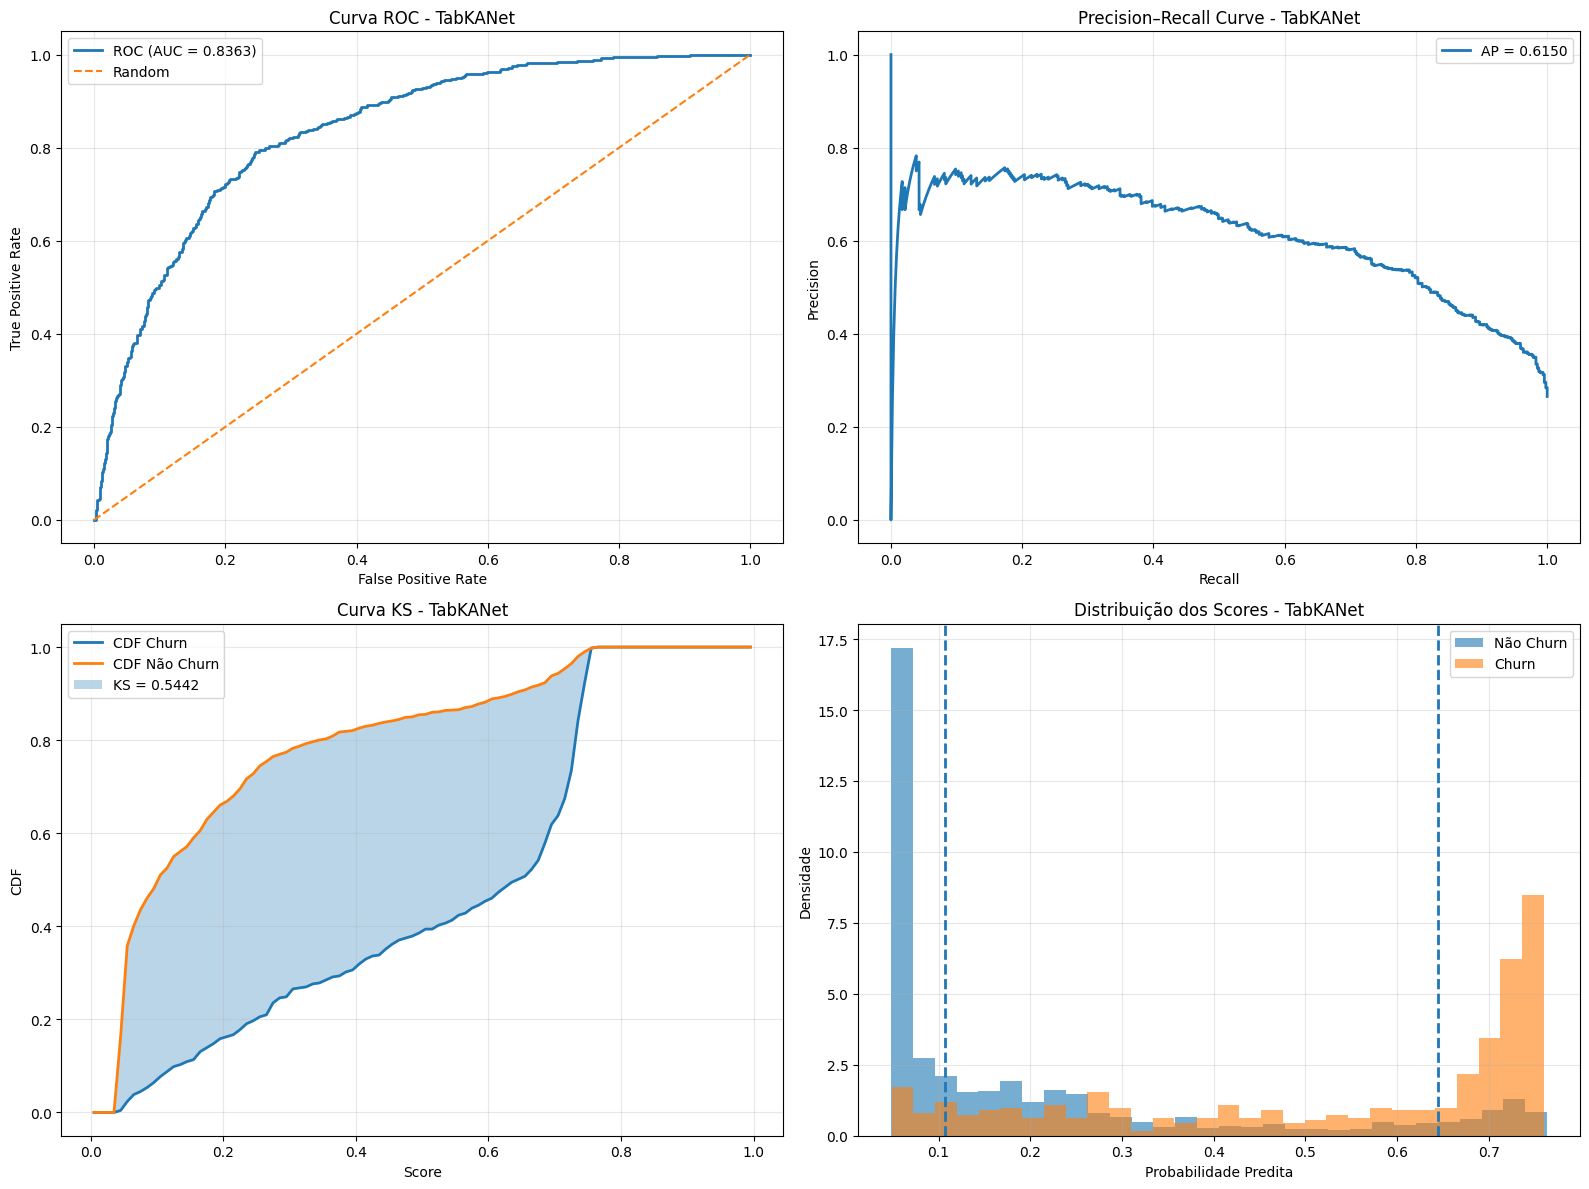

In [ ]:
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_recall_curve, average_precision_score,
    mean_squared_error, log_loss, roc_curve
)

model.eval()

y_true = []
y_prob = []
y_pred = []

with torch.no_grad():
    for cat, cont, y in val_loader:
        cat = cat.to(device)
        cont = cont.to(device)

        logits = model(cat, cont)
        probs = torch.softmax(logits, dim=1)[:, 1]

        y_prob.extend(probs.cpu().numpy())
        y_pred.extend((probs > 0.5).long().cpu().numpy())
        y_true.extend(y.numpy())

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = np.array(y_pred)

plt.figure(figsize=(16, 12))

# ================= ROC =================
ax_roc = plt.subplot(2, 2, 1)

fpr, tpr, _ = roc_curve(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)

ax_roc.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {auc:.4f})')
ax_roc.plot([0, 1], [0, 1], linestyle='--', label='Random')

ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("Curva ROC - TabKANet")
ax_roc.legend()
ax_roc.grid(True, alpha=0.3)

# ============ Precision–Recall ============
ax_pr = plt.subplot(2, 2, 2)

precision, recall, _ = precision_recall_curve(y_true, y_prob)
ap = average_precision_score(y_true, y_prob)

ax_pr.plot(recall, precision, lw=2, label=f"AP = {ap:.4f}")
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision–Recall Curve - TabKANet")
ax_pr.legend()
ax_pr.grid(True, alpha=0.3)

# ================= KS =================
ax_ks = plt.subplot(2, 2, 3)

y_prob_pos = y_prob[y_true == 1]
y_prob_neg = y_prob[y_true == 0]

bins = np.linspace(0, 1, 101)

pos_hist, _ = np.histogram(y_prob_pos, bins=bins, density=True)
neg_hist, _ = np.histogram(y_prob_neg, bins=bins, density=True)

cum_pos = np.cumsum(pos_hist) / np.sum(pos_hist)
cum_neg = np.cumsum(neg_hist) / np.sum(neg_hist)

bin_centers = (bins[:-1] + bins[1:]) / 2

ax_ks.plot(bin_centers, cum_pos, label="CDF Churn", lw=2)
ax_ks.plot(bin_centers, cum_neg, label="CDF Não Churn", lw=2)

ks_value = ks_statistic(y_true, y_prob)

ax_ks.fill_between(
    bin_centers, cum_pos, cum_neg,
    alpha=0.3, label=f"KS = {ks_value:.4f}"
)

ax_ks.set_xlabel("Score")
ax_ks.set_ylabel("CDF")
ax_ks.set_title("Curva KS - TabKANet")
ax_ks.legend()
ax_ks.grid(True, alpha=0.3)

# ============ Distribuição Scores ============
ax_dist = plt.subplot(2, 2, 4)

ax_dist.hist(y_prob_neg, bins=30, alpha=0.6, density=True, label="Não Churn")
ax_dist.hist(y_prob_pos, bins=30, alpha=0.6, density=True, label="Churn")

ax_dist.axvline(np.median(y_prob_neg), linestyle="--", lw=2)
ax_dist.axvline(np.median(y_prob_pos), linestyle="--", lw=2)

ax_dist.set_xlabel("Probabilidade Predita")
ax_dist.set_ylabel("Densidade")
ax_dist.set_title("Distribuição dos Scores - TabKANet")
ax_dist.legend()
ax_dist.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## TabPFN

### Instalação e import

In [ ]:
try:
    from tabpfn import TabPFNClassifier
    from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import AutoTabPFNClassifier
    print("TabPFN já instalado.")
except ImportError:
    print("Instalando TabPFN...")
    !pip install tabpfn
    !pip install "tabpfn-extensions[all] @ git+https://github.com/PriorLabs/tabpfn-extensions.git"
    from tabpfn import TabPFNClassifier
    from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import AutoTabPFNClassifier

import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    log_loss
)
from scipy.stats import ks_2samp
import os

os.environ["HF_TOKEN"] = "a_curiosidade_matou_o_gato"

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Instalando TabPFN...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.2/553.2 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.7/144.7 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.0 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
  Cloning https://github.com/PriorLabs/tabpfn-extensions.git to /tmp/pip-install-p63ja_t3/tabpfn-extensions_5f14655f499f4c5ab4d6bf4da64c9c44
  Running command git clone --filter=blob:none --quiet https://github.com/PriorLabs/tabpfn-extensions.git /tmp/pip-install-p63ja_t3/tabpfn-extensions_5f14655f499f

### Funções auxiliares

In [ ]:
def ks_statistic(y_true, y_prob):
    y_true = np.asarray(y_true).ravel()
    y_prob = np.asarray(y_prob).ravel()

    n = min(len(y_true), len(y_prob))
    y_true = y_true[:n]
    y_prob = y_prob[:n]

    pos = np.sort(y_prob[y_true == 1])
    neg = np.sort(y_prob[y_true == 0])

    all_scores = np.sort(np.concatenate([pos, neg]))

    cdf_pos = np.searchsorted(pos, all_scores, side="right") / len(pos)
    cdf_neg = np.searchsorted(neg, all_scores, side="right") / len(neg)

    return np.max(np.abs(cdf_pos - cdf_neg))

### Preparação dos Dados

In [ ]:
X_train_tabpfn = X_train.values
X_val_tabpfn   = X_val.values
X_test_tabpfn  = X_test.values

y_train_np = y_train.values.astype(int)
y_val_np   = y_val.values.astype(int)
y_test_np  = y_test.values.astype(int)

### Treino e resultados

In [ ]:
clf = AutoTabPFNClassifier(
    device="auto",
    max_time=180
)

clf.fit(X_train_tabpfn, y_train_np)

tabpfn-v2.5-classifier-v2.5_default.ckpt:   0%|          | 0.00/42.9M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

tabpfn-v2.5-classifier-v2.5_default-2.ck(…):   0%|          | 0.00/42.9M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

tabpfn-v2.5-classifier-v2.5_large-featur(…):   0%|          | 0.00/42.9M [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

tabpfn-v2.5-classifier-v2.5_variant.ckpt:   0%|          | 0.00/42.9M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

		'kdi_alpha_0.3'
Detailed Traceback:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/autogluon/tabular/trainer/abstract_trainer.py", line 2171, in _train_and_save
    model = self._train_single(**model_fit_kwargs)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/autogluon/tabular/trainer/abstract_trainer.py", line 2055, in _train_single
    model = model.fit(X=X, y=y, X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test, total_resources=total_resources, **model_fit_kwargs)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/autogluon/core/models/abstract/abstract_model.py", line 1068, in fit
    out = self._fit(**kwargs)
          ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/autogluon/core/models/ensemble/stacker_ensemble_model.py", line 270,

AutoTabPFNClassifier(max_time=180)

======= MÉTRICAS TABPFN (VALIDAÇÃO) =======
KS:        0.5635
AUROC:    0.8609
Acurácia: 0.8148
F1-score: 0.5925
LogLoss:  0.3984
MSE:      0.1287


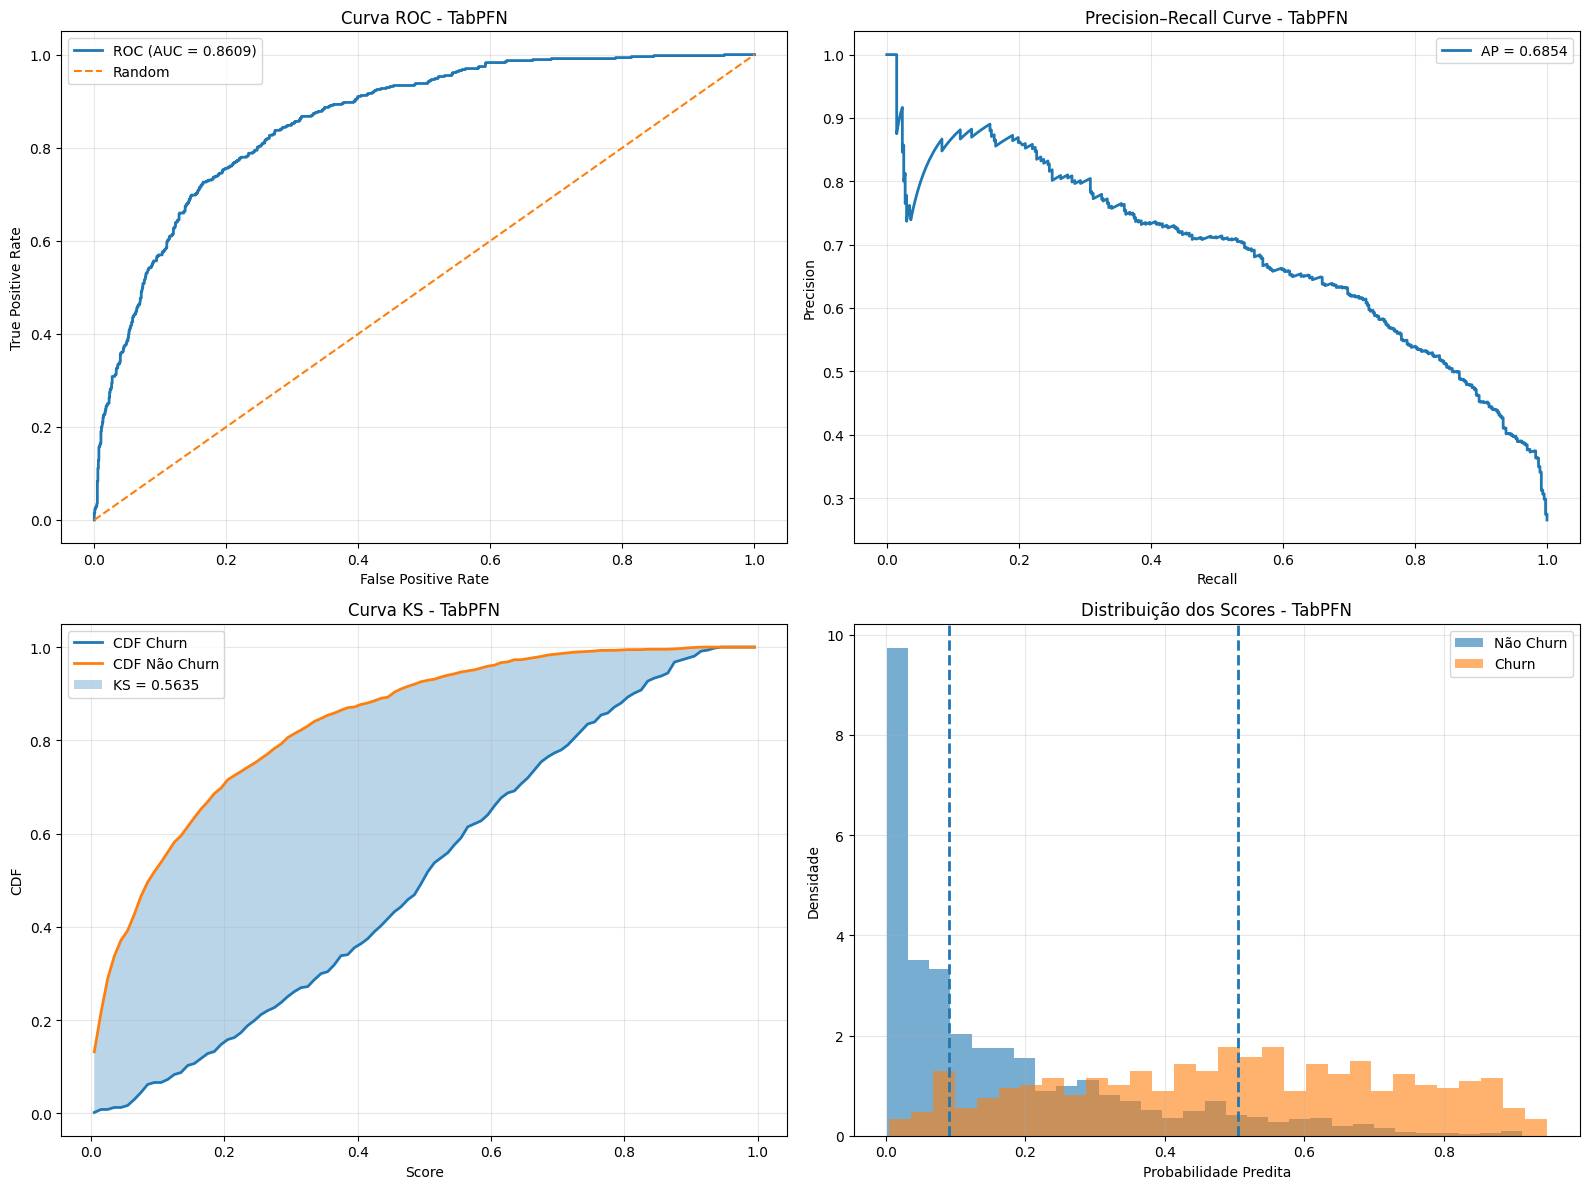

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_recall_curve, average_precision_score,
    mean_squared_error, log_loss, roc_curve
)

# ================= PREDIÇÕES TABPFN =================
y_val_prob = clf.predict_proba(X_val_tabpfn)[:, 1]

# ================= DADOS DE AVALIAÇÃO =================
y_true = y_val_np
y_prob = y_val_prob

# ================= CONSISTÊNCIA =================
y_true = np.asarray(y_true).ravel()
y_prob = np.asarray(y_prob).ravel()

n = min(len(y_true), len(y_prob))
y_true = y_true[:n]
y_prob = y_prob[:n]

y_pred = (y_prob >= 0.5).astype(int)

# ================= MÉTRICAS =================
ks_final = ks_statistic(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)

print("======= MÉTRICAS TABPFN (VALIDAÇÃO) =======")
print(f"KS:        {ks_final:.4f}")
print(f"AUROC:    {auc:.4f}")
print(f"Acurácia: {accuracy_score(y_true, y_pred):.4f}")
print(f"F1-score: {f1_score(y_true, y_pred):.4f}")
print(f"LogLoss:  {log_loss(y_true, y_prob):.4f}")
print(f"MSE:      {mean_squared_error(y_true, y_prob):.4f}")

# ================= DADOS TABPFN =================
y_true = np.asarray(y_val_np).ravel()
y_prob = np.asarray(y_val_prob).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# ================= FIGURA =================
plt.figure(figsize=(16, 12))

# ================= ROC =================
ax_roc = plt.subplot(2, 2, 1)

fpr, tpr, _ = roc_curve(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)

ax_roc.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {auc:.4f})')
ax_roc.plot([0, 1], [0, 1], linestyle='--', label='Random')

ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("Curva ROC - TabPFN")
ax_roc.legend()
ax_roc.grid(True, alpha=0.3)

# ============ Precision–Recall ============
ax_pr = plt.subplot(2, 2, 2)

precision, recall, _ = precision_recall_curve(y_true, y_prob)
ap = average_precision_score(y_true, y_prob)

ax_pr.plot(recall, precision, lw=2, label=f"AP = {ap:.4f}")
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision–Recall Curve - TabPFN")
ax_pr.legend()
ax_pr.grid(True, alpha=0.3)

# ================= KS =================
ax_ks = plt.subplot(2, 2, 3)

y_prob_pos = y_prob[y_true == 1]
y_prob_neg = y_prob[y_true == 0]

bins = np.linspace(0, 1, 101)

pos_hist, _ = np.histogram(y_prob_pos, bins=bins, density=True)
neg_hist, _ = np.histogram(y_prob_neg, bins=bins, density=True)

cum_pos = np.cumsum(pos_hist) / np.sum(pos_hist)
cum_neg = np.cumsum(neg_hist) / np.sum(neg_hist)

bin_centers = (bins[:-1] + bins[1:]) / 2

ax_ks.plot(bin_centers, cum_pos, label="CDF Churn", lw=2)
ax_ks.plot(bin_centers, cum_neg, label="CDF Não Churn", lw=2)

ks_value = ks_statistic(y_true, y_prob)

ax_ks.fill_between(
    bin_centers, cum_pos, cum_neg,
    alpha=0.3, label=f"KS = {ks_value:.4f}"
)

ax_ks.set_xlabel("Score")
ax_ks.set_ylabel("CDF")
ax_ks.set_title("Curva KS - TabPFN")
ax_ks.legend()
ax_ks.grid(True, alpha=0.3)

# ============ Distribuição Scores ============
ax_dist = plt.subplot(2, 2, 4)

ax_dist.hist(y_prob_neg, bins=30, alpha=0.6, density=True, label="Não Churn")
ax_dist.hist(y_prob_pos, bins=30, alpha=0.6, density=True, label="Churn")

ax_dist.axvline(np.median(y_prob_neg), linestyle="--", lw=2)
ax_dist.axvline(np.median(y_prob_pos), linestyle="--", lw=2)

ax_dist.set_xlabel("Probabilidade Predita")
ax_dist.set_ylabel("Densidade")
ax_dist.set_title("Distribuição dos Scores - TabPFN")
ax_dist.legend()
ax_dist.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Mitra

### Imports

In [ ]:
!pip install -q optuna

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import optuna

from sklearn.metrics import roc_curve

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 23.4 MB/s eta 0:00:00
Device: cuda


### Preparação dos dados

In [ ]:
# ================= FUNÇÃO AUXILIAR SEGURA =================
def ensure_tensor(y, device):
    if isinstance(y, torch.Tensor):
        return y.to(device).long()
    else:
        return torch.tensor(y.to_numpy(), dtype=torch.long).to(device)

# ================= TREINO =================
X_train = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train = ensure_tensor(y_train_bal, device)

# ================= VALIDAÇÃO =================
X_val = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
y_val_t = ensure_tensor(y_val, device)

# ================= TESTE =================
X_test = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_t = ensure_tensor(y_test, device)

print("Shapes:")
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val_t.shape)
print(X_test.shape, y_test_t.shape)

Shapes:
torch.Size([5174, 30]) torch.Size([5174])
torch.Size([1760, 30]) torch.Size([1760])
torch.Size([1762, 30]) torch.Size([1762])


### Função KS

In [ ]:
def ks_statistic(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return np.max(tpr - fpr)


### Modelo MITRA

In [ ]:
class MITRA(nn.Module):
    def __init__(
        self,
        input_dim,
        embed_dim,
        num_heads,
        num_layers,
        dropout
    ):
        super().__init__()

        self.embedding = nn.Linear(1, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 2)
        )

    def forward(self, x):
        x = x.unsqueeze(-1)      # (batch, features, 1)
        x = self.embedding(x)   # (batch, features, embed_dim)
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.classifier(x)

### Função Treino

In [ ]:
def train_epoch(model, X, y, optimizer, criterion, batch_size):
    model.train()
    perm = torch.randperm(X.size(0), device=device)
    total_loss = 0

    for i in range(0, X.size(0), batch_size):
        idx = perm[i:i + batch_size]
        xb, yb = X[idx], y[idx]

        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

    return total_loss / X.size(0)

Função Objetivo Optuna

In [ ]:
def objective(trial):

    embed_dim = trial.suggest_categorical("embed_dim", [32, 64, 128])
    num_heads = trial.suggest_categorical("num_heads", [2, 4, 8])

    if embed_dim % num_heads != 0:
        raise optuna.TrialPruned()

    num_layers = trial.suggest_int("num_layers", 1, 3)
    dropout = trial.suggest_float("dropout", 0.0, 0.3)
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [128, 256, 512])

    model = MITRA(
        input_dim=input_dim,
        embed_dim=embed_dim,
        num_heads=num_heads,
        num_layers=num_layers,
        dropout=dropout
    ).to(device)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    criterion = nn.CrossEntropyLoss()

    epochs = 15  # curto para Optuna

    for _ in range(epochs):
        train_epoch(
            model,
            X_train,
            y_train,
            optimizer,
            criterion,
            batch_size
        )

    # ===== Avaliação KS =====
    model.eval()
    with torch.no_grad():
        logits = model(X_val)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

    ks = ks_statistic(y_val_t.cpu().numpy(), probs)
    return ks

### Procura de Hiperparâmetros Optuna

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("🔥 Melhor KS:", study.best_value)
print("⚙️ Melhores hiperparâmetros:")
study.best_params

[I 2025-12-17 02:24:28,859] A new study created in memory with name: no-name-5ce70c71-0a4a-43d0-81c0-e94c56891d70
[I 2025-12-17 02:24:39,635] Trial 0 finished with value: 0.4895459159930511 and parameters: {'embed_dim': 128, 'num_heads': 8, 'num_layers': 2, 'dropout': 0.1587418138936846, 'lr': 0.00022294710689100815, 'weight_decay': 2.824976655058204e-05, 'batch_size': 128}. Best is trial 0 with value: 0.4895459159930511.
[I 2025-12-17 02:24:47,877] Trial 1 finished with value: 0.4986328956280814 and parameters: {'embed_dim': 64, 'num_heads': 8, 'num_layers': 2, 'dropout': 0.05318814228523578, 'lr': 0.0006490006517584242, 'weight_decay': 1.2801656316237648e-06, 'batch_size': 128}. Best is trial 1 with value: 0.4986328956280814.
[I 2025-12-17 02:24:52,631] Trial 2 finished with value: 0.48679514632405424 and parameters: {'embed_dim': 32, 'num_heads': 2, 'num_layers': 2, 'dropout': 0.06266229617382094, 'lr': 0.00242752868482518, 'weight_decay': 4.281018392158349e-06, 'batch_size': 512}. 

🔥 Melhor KS: 0.4986328956280814
⚙️ Melhores hiperparâmetros:


{'embed_dim': 64,
 'num_heads': 8,
 'num_layers': 2,
 'dropout': 0.05318814228523578,
 'lr': 0.0006490006517584242,
 'weight_decay': 1.2801656316237648e-06,
 'batch_size': 128}

### Treinamento com modelo final

In [ ]:
best = study.best_params

model = MITRA(
    input_dim=input_dim,
    embed_dim=best["embed_dim"],
    num_heads=best["num_heads"],
    num_layers=best["num_layers"],
    dropout=best["dropout"]
).to(device)

optimizer = optim.AdamW(
    model.parameters(),
    lr=best["lr"],
    weight_decay=best["weight_decay"]
)

criterion = nn.CrossEntropyLoss()

epochs = 40
batch_size = best["batch_size"]

for epoch in range(1, epochs + 1):
    loss = train_epoch(
        model,
        X_train,
        y_train,
        optimizer,
        criterion,
        batch_size
    )

    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(X_val), dim=1)[:, 1].cpu().numpy()
        ks = ks_statistic(y_val_t.cpu().numpy(), probs)

    print(f"Epoch {epoch:02d} | Loss: {loss:.4f} | KS Val: {ks:.4f}")

Epoch 01 | Loss: 0.6819 | KS Val: 0.4169
Epoch 02 | Loss: 0.5968 | KS Val: 0.4575
Epoch 03 | Loss: 0.5776 | KS Val: 0.4770
Epoch 04 | Loss: 0.5732 | KS Val: 0.4785
Epoch 05 | Loss: 0.5731 | KS Val: 0.4783
Epoch 06 | Loss: 0.5705 | KS Val: 0.4911
Epoch 07 | Loss: 0.5718 | KS Val: 0.4831
Epoch 08 | Loss: 0.5673 | KS Val: 0.4945
Epoch 09 | Loss: 0.5680 | KS Val: 0.4918
Epoch 10 | Loss: 0.5622 | KS Val: 0.4988
Epoch 11 | Loss: 0.5576 | KS Val: 0.4825
Epoch 12 | Loss: 0.5644 | KS Val: 0.4937
Epoch 13 | Loss: 0.5608 | KS Val: 0.4837
Epoch 14 | Loss: 0.5641 | KS Val: 0.4917
Epoch 15 | Loss: 0.5586 | KS Val: 0.4900
Epoch 16 | Loss: 0.5592 | KS Val: 0.4924
Epoch 17 | Loss: 0.5574 | KS Val: 0.4922
Epoch 18 | Loss: 0.5540 | KS Val: 0.4941
Epoch 19 | Loss: 0.5586 | KS Val: 0.4876
Epoch 20 | Loss: 0.5536 | KS Val: 0.4897
Epoch 21 | Loss: 0.5505 | KS Val: 0.4917
Epoch 22 | Loss: 0.5477 | KS Val: 0.4885
Epoch 23 | Loss: 0.5528 | KS Val: 0.4952
Epoch 24 | Loss: 0.5492 | KS Val: 0.4926
Epoch 25 | Loss:

### Resultados

======= MÉTRICAS MITRA (VALIDAÇÃO) =======
KS:        0.4863
AUROC:    0.8094
Acurácia: 0.7273
F1-score: 0.5993
LogLoss:  0.5473
MSE:      0.1852


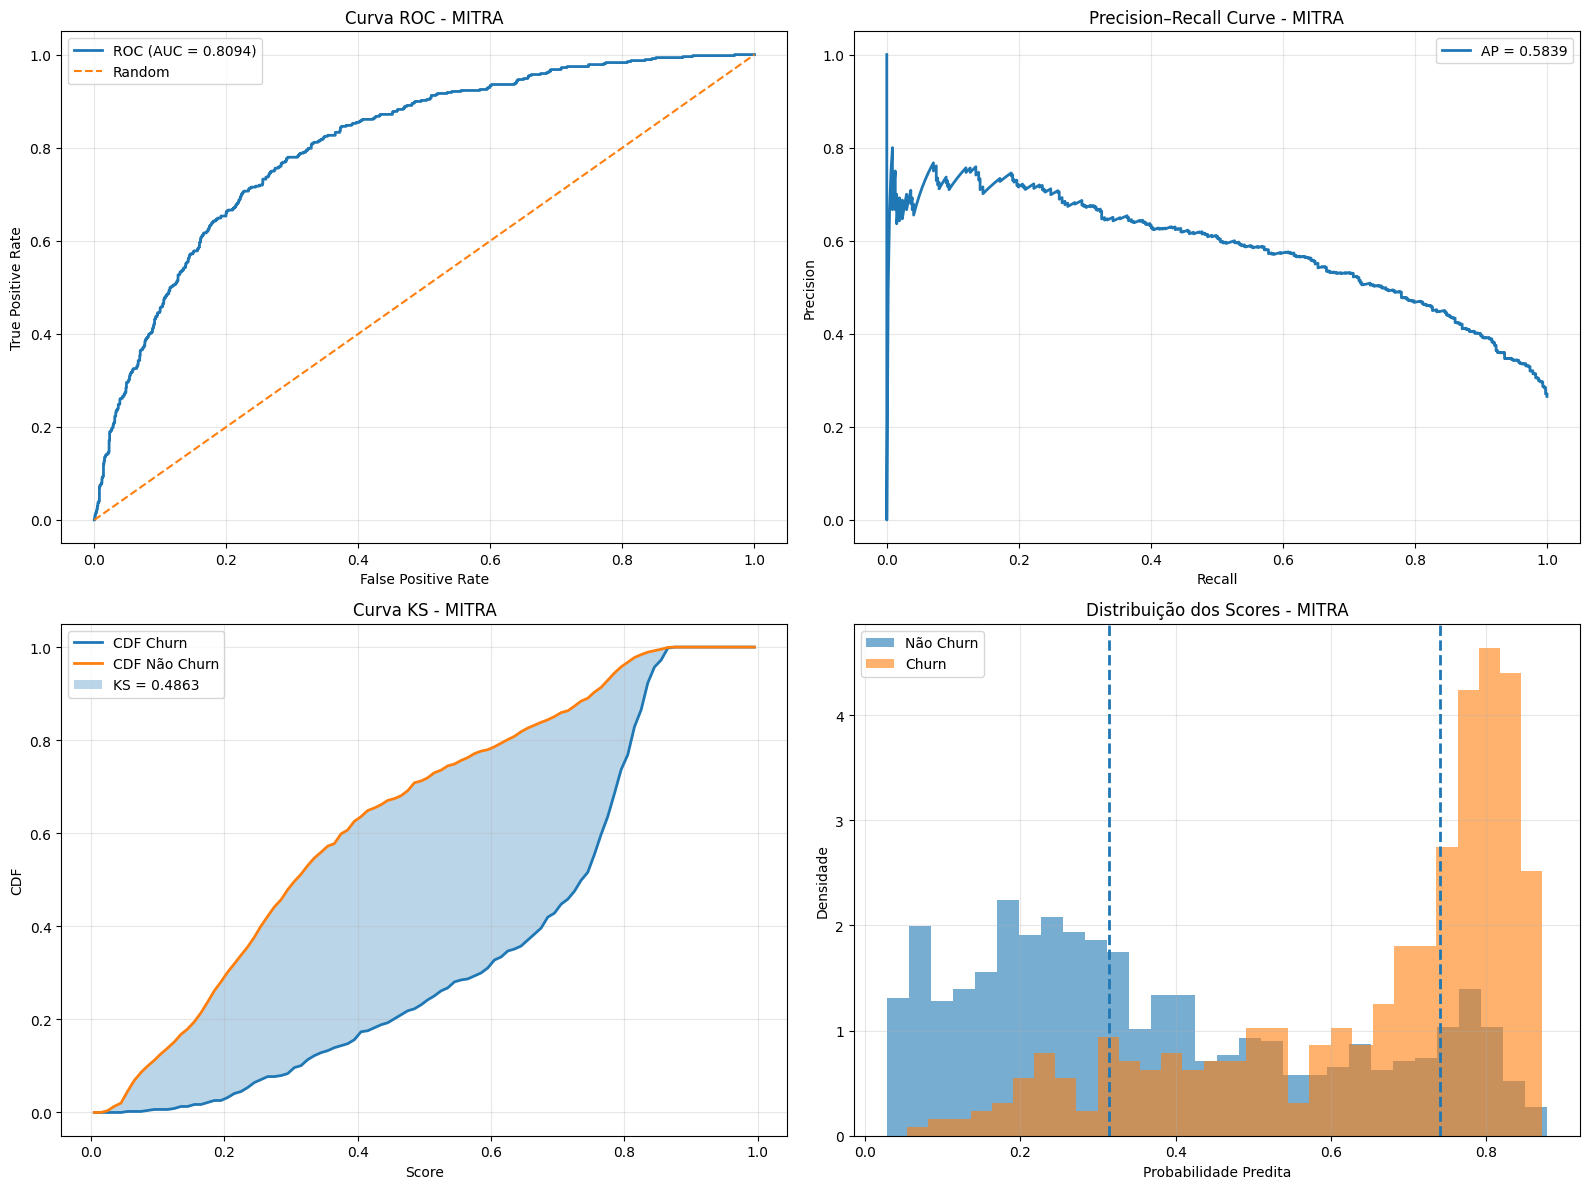

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_recall_curve, average_precision_score,
    mean_squared_error, log_loss, roc_curve
)

# ================= PREDIÇÕES MITRA =================
model.eval()
with torch.no_grad():
    logits = model(X_val)
    y_val_prob = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

# ================= DADOS DE AVALIAÇÃO =================
y_true = y_val_t.cpu().numpy()
y_prob = y_val_prob

# ================= CONSISTÊNCIA =================
y_true = np.asarray(y_true).ravel()
y_prob = np.asarray(y_prob).ravel()

n = min(len(y_true), len(y_prob))
y_true = y_true[:n]
y_prob = y_prob[:n]

y_pred = (y_prob >= 0.5).astype(int)

# ================= MÉTRICAS =================
ks_final = ks_statistic(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)

print("======= MÉTRICAS MITRA (VALIDAÇÃO) =======")
print(f"KS:        {ks_final:.4f}")
print(f"AUROC:    {auc:.4f}")
print(f"Acurácia: {accuracy_score(y_true, y_pred):.4f}")
print(f"F1-score: {f1_score(y_true, y_pred):.4f}")
print(f"LogLoss:  {log_loss(y_true, y_prob):.4f}")
print(f"MSE:      {mean_squared_error(y_true, y_prob):.4f}")

# ================= FIGURA =================
plt.figure(figsize=(16, 12))

# ================= ROC =================
ax_roc = plt.subplot(2, 2, 1)

fpr, tpr, _ = roc_curve(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)

ax_roc.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {auc:.4f})')
ax_roc.plot([0, 1], [0, 1], linestyle='--', label='Random')

ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("Curva ROC - MITRA")
ax_roc.legend()
ax_roc.grid(True, alpha=0.3)

# ============ Precision–Recall ============
ax_pr = plt.subplot(2, 2, 2)

precision, recall, _ = precision_recall_curve(y_true, y_prob)
ap = average_precision_score(y_true, y_prob)

ax_pr.plot(recall, precision, lw=2, label=f"AP = {ap:.4f}")
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision–Recall Curve - MITRA")
ax_pr.legend()
ax_pr.grid(True, alpha=0.3)

# ================= KS =================
ax_ks = plt.subplot(2, 2, 3)

y_prob_pos = y_prob[y_true == 1]
y_prob_neg = y_prob[y_true == 0]

bins = np.linspace(0, 1, 101)

pos_hist, _ = np.histogram(y_prob_pos, bins=bins, density=True)
neg_hist, _ = np.histogram(y_prob_neg, bins=bins, density=True)

cum_pos = np.cumsum(pos_hist) / np.sum(pos_hist)
cum_neg = np.cumsum(neg_hist) / np.sum(neg_hist)

bin_centers = (bins[:-1] + bins[1:]) / 2

ax_ks.plot(bin_centers, cum_pos, label="CDF Churn", lw=2)
ax_ks.plot(bin_centers, cum_neg, label="CDF Não Churn", lw=2)

ax_ks.fill_between(
    bin_centers, cum_pos, cum_neg,
    alpha=0.3, label=f"KS = {ks_final:.4f}"
)

ax_ks.set_xlabel("Score")
ax_ks.set_ylabel("CDF")
ax_ks.set_title("Curva KS - MITRA")
ax_ks.legend()
ax_ks.grid(True, alpha=0.3)

# ============ Distribuição Scores ============
ax_dist = plt.subplot(2, 2, 4)

ax_dist.hist(y_prob_neg, bins=30, alpha=0.6, density=True, label="Não Churn")
ax_dist.hist(y_prob_pos, bins=30, alpha=0.6, density=True, label="Churn")

ax_dist.axvline(np.median(y_prob_neg), linestyle="--", lw=2)
ax_dist.axvline(np.median(y_prob_pos), linestyle="--", lw=2)

ax_dist.set_xlabel("Probabilidade Predita")
ax_dist.set_ylabel("Densidade")
ax_dist.set_title("Distribuição dos Scores - MITRA")
ax_dist.legend()
ax_dist.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()